# Gateway

This code performs a comprehensive end-to-end process for analyzing race telemetry data from a karting session. It takes raw sensor data from a SQLite database and transforms it into a structured, enhanced dataset with lap and sector information. Here's what it does:

Data Ingestion & Integration:

Loads GPS (Location) data from a SQLite database
Loads and merges multiple sensor tables (Orientation, Compass, Accelerometer, Gyroscope, Magnetometer)
Cleans GPS data by removing anomalous points with unrealistic speeds
Sensor Fusion & Data Enhancement:

Combines GPS and IMU (Inertial Measurement Unit) data using advanced techniques
Converts GPS coordinates to local XY coordinates in meters for better calculations
Uses spline interpolation for smooth trajectory
Applies a blended approach between GPS and dead reckoning for optimal positioning
Applies low-pass filters to reduce noise in the data
Calculates derived metrics like speed, bearing, lateral/longitudinal acceleration
Lap and Sector Segmentation:

Identifies when the kart crosses predefined lines for start/finish and sector boundaries
Counts laps and categorizes them as 'out', 'warm-up', 'timed', or 'exit' laps
Calculates sector times for performance analysis
Computes lap-specific timing information
Data Enrichment & Conversion:

Calculates G-forces with appropriate scaling for karting
Smooths G-force data for better visualization
Converts speed from meters per second to miles per hour
Clips extreme G-force values to remove outliers
Data Preparation & Export:

Rounds values to appropriate decimal places based on their type
Filters the dataset to focus on 'timed' laps (the actual racing laps)
Saves the processed telemetry data to a CSV file
This code is designed for a race track with three sectors, using specific geographic coordinates for the Gateway track (in St. Louis, based on the coordinates). It provides a rich dataset that can be used for race analysis, driver performance evaluation, and visualization in racing analysis tools like Kepler.

In [47]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce

# --- Configuration ---
db_path = './700_IL-203_S-2025-10-16_22-31-59.sqlite'              # input
telemetry_csv = './700_IL-203_S-2025-10-16_22-31-59-2.telemetry.csv' # output
race_id = 5
scaling_factor = 0.3 # G-force scaling factor for karting
MPS_TO_MPH = 2.23694 # Meters per second to Miles per hour conversion factor

# Define start/finish and sector boundary lines
sf_line = LineString([(38.64886, -90.13461), (38.64888, -90.13440)])
s1_s2_line = LineString([(38.64918, -90.13474), (38.64911, -90.13491)])
s2_s3_line = LineString([(38.64868, -90.13454), (38.64852, -90.13473)])



# --- Step 1: Data Ingestion & Integration (in-memory) ---
print("--- Step 1: Data Ingestion ---")
try:
    conn = sqlite3.connect(db_path)
    
    # Read Location (GPS) data
    print("Reading Location table into DataFrame...")
    gps_df = pd.read_sql_query("SELECT * FROM Location", conn)
    
    # Read all sensor data and prepare for merge
    print("Reading all sensor tables and preparing for merge...")
    tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
    list_of_dfs = []
    
    for table_name in tables_to_join:
        df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
        list_of_dfs.append(df_temp)
    
    # Merge all sensor dataframes on a common timestamp
    main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
    
    conn.close()
    
    print("Initial data loaded and merged successfully.")

except Exception as e:
    print(f"Error during data ingestion: {e}")
    if 'conn' in locals():
        conn.close()
    raise

# --- Clean GPS data ---
print("Cleaning GPS data...")
gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
anomaly_indices = []
for i in range(1, len(gps_df)):
    prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
    curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
    distance = haversine(prev_point, curr_point, unit='m')
    time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
    if time_diff < 0.01: time_diff = 0.01
    speed = distance / time_diff
    if speed > 50:
        anomaly_indices.append(i)
if anomaly_indices:
    gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
gps_df['altitude'] = 0.0

# --- Step 2: Sensor Fusion & Data Enhancement ---
print("\n--- Step 2: Sensor Fusion & Enhancement ---")

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lat) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

# Time vectors
gps_time = gps_df['seconds_elapsed'].values
imu_time = main_df['seconds_elapsed'].values
dt = np.mean(np.diff(imu_time))

# Convert GPS to local coordinates
ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

# Get GPS speed and bearing
gps_speed = gps_df['speed'].values
gps_bearing = gps_df['bearing'].values
dx, dy = np.diff(gps_x), np.diff(gps_y)
computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

# Interpolate GPS positions with spline for smoothness
spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

# Fusing IMU data for improved precision
fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
base_heading = interp_bearing
heading = np.zeros_like(base_heading)
heading[0] = base_heading[0]
alpha = 0.98
for i in range(1, len(imu_time)):
    gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
    time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
    blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
    imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
    heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

heading_rad = np.radians(heading)
vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
for i in range(1, len(imu_time)):
    dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
    gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
    time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
    weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
    fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
    fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=100)
fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=100)
fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
accel_long = np.diff(fused_speed) / dt
accel_long = np.concatenate([[0], accel_long])
turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=100)
accel_lat = fused_speed * np.radians(turn_rate)

# Create final DataFrame
telemetry_df = main_df.copy()
telemetry_df['latitude'] = fused_lat
telemetry_df['longitude'] = fused_lon
telemetry_df['speed'] = fused_speed
telemetry_df['bearing'] = fused_bearing
telemetry_df['accel_longitudinal'] = accel_long
telemetry_df['accel_lateral'] = accel_lat
telemetry_df['turn_rate'] = turn_rate
telemetry_df['race'] = race_id

# --- Step 3: Lap and Sector Segmentation ---
print("\n--- Step 3: Lap and Sector Segmentation ---")

# Lap Segmentation
lap_number, lap_numbers = 0, []
prev_point = None
for i, row in telemetry_df.iterrows():
    current_point = Point(row['latitude'], row['longitude'])
    if prev_point is None:
        prev_point = current_point
        lap_numbers.append(lap_number)
        continue
    segment = LineString([prev_point, current_point])
    if segment.intersects(sf_line):
        lap_number += 1
    lap_numbers.append(lap_number)
    prev_point = current_point
telemetry_df['lap'] = lap_numbers
total_laps = lap_number

def get_lap_name(lap_num):
    if lap_num == 0: return 'out'
    elif lap_num == 1: return 'warm-up'
    elif lap_num == total_laps: return 'exit'
    else: return 'timed'
telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
telemetry_df['lap'] = telemetry_df['numbered_lap']
telemetry_df.drop(columns=['numbered_lap'], inplace=True)

# Sector Segmentation
telemetry_df['sector'] = 0
telemetry_df['sector_time'] = np.nan
sector_number = 1
sector_times = {}
prev_point = None
prev_lap = None  # Track lap changes
sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

for i, row in telemetry_df.iterrows():
    current_point = Point(row['latitude'], row['longitude'])
    current_lap = row['lap']
    
    # Reset sector counter when lap changes
    if prev_lap is not None and current_lap != prev_lap:
        sector_number = 1
        sector_start_time = row['seconds_elapsed']
    
    if i > 0:
        segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
        
        # Sector crossing logic (same as before)
        if sector_number == 1 and segment.intersects(s1_s2_line):
            distance_to_line = current_point.distance(s1_s2_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 1)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 2
                
        elif sector_number == 2 and segment.intersects(s2_s3_line):
            distance_to_line = current_point.distance(s2_s3_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 2)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 3
                
        elif sector_number == 3 and segment.intersects(sf_line):
            distance_to_line = current_point.distance(sf_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 3)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 1  # This already resets, but explicit

    telemetry_df.loc[i, 'sector'] = sector_number
    prev_point = current_point
    prev_lap = current_lap

# Print diagnostics
print("\nSector crossings detected:")
for (lap, sector), time in sorted(sector_times.items()):
    print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

# Process 'timed' laps
filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
if not filtered_df.empty:
    start_time = filtered_df['race_seconds_elapsed'].iloc[0]
    filtered_df['race_seconds_elapsed'] -= start_time
    filtered_df['lap_seconds_elapsed'] = 0.0
    for lap_num in filtered_df['lap'].unique():
        lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
        if not lap_indices.empty:
            lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
            filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

# Calculate G-force and smooth
filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
window_size = 7
filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
upper_limit = filtered_df['g_force'].quantile(0.98)
filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

# --- Final Rounding and Conversion Step ---
print("\n--- Final Rounding and Conversion ---")

# CONVERSION: Speed (m/s) to Speed (mph)
filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

# Round time-based columns to 2 decimal places (100 Hz precision)
filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

# Round derived kinematics for readability
filtered_df['speed'] = filtered_df['speed'].round(2)
filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1) # Round mph to 1 decimal place
filtered_df['bearing'] = filtered_df['bearing'].round(1)
filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
filtered_df['g_force'] = filtered_df['g_force'].round(2)
filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

# Round raw sensor data for readability (using defensive column checks)
for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
            'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
            'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
            'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
    if col in filtered_df.columns:
        filtered_df[col] = filtered_df[col].round(4)


print("\nProcessing complete. Final data is in the `filtered_df` DataFrame.")

# To save the final result to a CSV
filtered_df.to_csv(telemetry_csv, index=False)
print(f'Final telemetry data saved to {telemetry_csv}')

filtered_df_10hz = filtered_df.iloc[::10].copy()  # Every 10th row (100Hz → 10Hz)
filtered_df_10hz.to_csv(telemetry_csv.replace('.csv', '_10hz.csv'), index=False)
print(f'10 Hz telemetry saved to {telemetry_csv.replace(".csv", "_10hz.csv")}')

--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...


KeyboardInterrupt: 

# CIRCUIT INFO

Info for labeling and positioning

In [ ]:
#!pip install ipyleaflet

In [ ]:
import json
import ipyleaflet
import numpy as np

# Load the GeoJSON file
with open('circuit.geojson', 'r') as f:
    geojson_data = json.load(f)

# Function to extract coordinates and find center
def get_center_from_geojson(geojson):
    all_coords = []
    
    # Extract all coordinates based on GeoJSON type
    if geojson['type'] == 'FeatureCollection':
        for feature in geojson['features']:
            geometry = feature['geometry']
            if geometry['type'] == 'Point':
                all_coords.append(geometry['coordinates'])
            elif geometry['type'] in ['LineString', 'MultiPoint']:
                all_coords.extend(geometry['coordinates'])
            elif geometry['type'] in ['Polygon', 'MultiLineString']:
                for line in geometry['coordinates']:
                    all_coords.extend(line)
            elif geometry['type'] == 'MultiPolygon':
                for polygon in geometry['coordinates']:
                    for line in polygon:
                        all_coords.extend(line)
    
    # If we have coordinates, calculate center
    if all_coords:
        # Note: GeoJSON uses [longitude, latitude] format
        lons = [coord[0] for coord in all_coords]
        lats = [coord[1] for coord in all_coords]
        center_lon = np.mean([min(lons), max(lons)])
        center_lat = np.mean([min(lats), max(lats)])
        return (center_lat, center_lon)  # ipyleaflet uses (lat, lon) format
    else:
        return (0, 0)  # Default center if no coordinates found

# Get the center of the GeoJSON
center = get_center_from_geojson(geojson_data)

# Create a map centered on the GeoJSON data
m = ipyleaflet.Map(center=center, zoom=10)

# Add the GeoJSON layer
geo_layer = ipyleaflet.GeoJSON(data=geojson_data)
m.add_layer(geo_layer)

# Display the map
m

Map(center=[38.64909480372239, -90.13486941505172], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
def identify_corners_from_aggregate_telemetry(telemetry_df, min_cluster_size=10):
    """
    Identify corners by analyzing all telemetry traces together, 
    accounting for varying racing lines from a learning driver
    """
    # 1. Extract key indicators of cornering behavior
    corner_indicators = telemetry_df.copy()
    
    # Absolute turn rate (direction doesn't matter for detection)
    corner_indicators['abs_turn_rate'] = abs(corner_indicators['turn_rate'])
    
    # Calculate speed change (negative values indicate braking)
    corner_indicators['speed_change'] = corner_indicators['speed'].diff().rolling(3).mean()
    
    # Calculate lateral G-force (indicator of cornering)
    corner_indicators['abs_lateral_g'] = abs(corner_indicators['accel_lateral'] * scaling_factor)
    
    # 2. Create a composite "cornering score" (higher = more likely a corner)
    corner_indicators['corner_score'] = (
        corner_indicators['abs_turn_rate'] / 10 +  # Normalized turn rate
        corner_indicators['abs_lateral_g'] * 3 +   # Weighted lateral G
        abs(corner_indicators['speed_change']) * (corner_indicators['speed_change'] < 0)  # Braking only
    )
    
    # 3. Select points that exceed cornering thresholds (multiple criteria)
    corner_candidates = corner_indicators[
        ((corner_indicators['abs_turn_rate'] > 15) &  # Sharp turning
         (corner_indicators['abs_lateral_g'] > 0.3))  # Significant lateral force
        |
        ((corner_indicators['abs_turn_rate'] > 10) &  # Moderate turning
         (corner_indicators['abs_lateral_g'] > 0.5) &  # High lateral force
         (corner_indicators['speed_change'] < -0.5))   # With braking
    ]
    
    # Only proceed if we have enough candidate points
    if len(corner_candidates) < min_cluster_size:
        return {}
    
    # 4. Cluster corner points using DBSCAN (handles irregular clusters well)
    from sklearn.cluster import DBSCAN
    
    # Use geographic coordinates for spatial clustering
    coords = corner_candidates[['latitude', 'longitude']].values
    
    # Clustering parameters tuned for kart tracks
    # - eps: maximum distance between points in same cluster (adjusted for GPS coordinates)
    # - min_samples: minimum points to form a cluster (adjusted for learning drivers taking different lines)
    clustering = DBSCAN(eps=0.000035, min_samples=min_cluster_size).fit(coords)
    corner_candidates['cluster'] = clustering.labels_
    
    # 5. Process each cluster to identify and characterize corners
    corners = {}
    valid_clusters = sorted(list(set(corner_candidates['cluster'].unique()) - {-1}))
    
    for i, cluster_id in enumerate(valid_clusters):
        cluster_points = corner_candidates[corner_candidates['cluster'] == cluster_id]
        
        # Calculate cluster center (average position)
        avg_lat = cluster_points['latitude'].mean()
        avg_lon = cluster_points['longitude'].mean()
        center = Point(avg_lon, avg_lat)
        
        # Determine corner characteristics
        avg_turn_rate = cluster_points['turn_rate'].mean()
        direction = 'left' if avg_turn_rate > 0 else 'right'
        severity = abs(cluster_points['corner_score'].mean())
        severity_category = 'hairpin' if severity > 8 else 'sharp' if severity > 5 else 'medium' if severity > 3 else 'gentle'
        
        # Speed characteristics (important for learning drivers)
        entry_speed = np.percentile(cluster_points['speed_mph'], 75)  # 75th percentile of speed
        min_speed = np.percentile(cluster_points['speed_mph'], 25)    # 25th percentile (avoiding outliers)
        exit_speed = np.percentile(cluster_points['speed_mph'], 75)   # 75th percentile
        
        # Calculate corner radius (in meters) using speed and lateral G
        # This uses the formula: radius = v² / (g * lateral_g)
        median_speed_mps = np.median(cluster_points['speed']) # m/s
        median_lateral_g = np.median(abs(cluster_points['accel_lateral'] * scaling_factor))
        if median_lateral_g > 0.1:  # Avoid division by small numbers
            radius = (median_speed_mps**2) / (9.8 * median_lateral_g)
        else:
            radius = float('inf')
        
        # Record corner information
        corners[i+1] = {  # Sequential numbering
            'center': center,
            'direction': direction,
            'severity': severity,
            'type': severity_category,
            'radius': round(radius, 1),
            'entry_speed_mph': round(entry_speed, 1),
            'min_speed_mph': round(min_speed, 1),
            'exit_speed_mph': round(exit_speed, 1),
            'speed_drop_mph': round(entry_speed - min_speed, 1),
            'points_count': len(cluster_points)
        }
    
    # 6. Order corners by track position (helps with sequential numbering)
    # This uses the start/finish line as reference and follows track direction
    # This step would require additional track layout knowledge
    
    return corners

def visualize_corners_with_heatmap(telemetry_df, corners, track_direction='clockwise'):
    """
    Visualize corners with a heat map showing cornering intensity,
    helpful for seeing the varying lines a learning driver takes
    """
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Create a heat map of cornering intensity
    corner_score = telemetry_df['turn_rate'].abs() * telemetry_df['g_force']
    
    # Plot the heat map using a scatter plot with color gradient
    sc = ax.scatter(
        telemetry_df['longitude'], 
        telemetry_df['latitude'], 
        c=corner_score,
        cmap='hot_r',  # Red-yellow-white color map
        s=1.5,
        alpha=0.6
    )
    cbar = plt.colorbar(sc)
    cbar.set_label('Corner Intensity (Turn Rate × G-Force)')
    
    # Plot lap traces in background (light blue)
    ax.plot(telemetry_df['longitude'], telemetry_df['latitude'], 'c-', linewidth=0.3, alpha=0.3)
    
    # Add detected corners with direction arrows
    for corner_num, corner_data in corners.items():
        center = corner_data['center']
        direction = corner_data['direction']
        severity = corner_data['severity']
        corner_type = corner_data['type']
        
        # Determine marker size based on corner severity
        marker_size = min(severity * 2, 20) + 8
        
        # Draw corner marker
        color = 'red' if direction == 'left' else 'blue'
        ax.plot(center.x, center.y, marker='o', markersize=marker_size, color=color, alpha=0.7)
        
        # Add direction arrow
        arrow_length = 0.00015
        if direction == 'left':
            dx, dy = arrow_length * np.sin(np.pi/4), arrow_length * np.cos(np.pi/4)
        else:
            dx, dy = -arrow_length * np.sin(np.pi/4), arrow_length * np.cos(np.pi/4)
            
        ax.arrow(center.x, center.y, dx, dy, head_width=0.00005, head_length=0.00005, 
                 fc=color, ec=color, alpha=0.7)
        
        # Add corner label with information
        ax.annotate(
            f"C{corner_num}: {corner_type} {direction}\n" + 
            f"{corner_data['min_speed_mph']} mph",
            (center.x, center.y),
            textcoords="offset points",
            xytext=(0, marker_size + 2),
            ha='center',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8)
        )
    
    # Add track direction indicator
    if track_direction:
        plt.annotate(
            f'Track Direction: {track_direction}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
        )
    
    plt.title('Corner Analysis with Varying Racing Lines')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.axis('equal')
    
    return fig

# Analysis of driving consistency through corners
def analyze_corner_consistency(telemetry_df, corners, timed_laps_only=True):
    """
    Analyze how consistently the driver takes each corner across different laps,
    useful for tracking learning progress
    """
    if timed_laps_only:
        lap_data = telemetry_df[telemetry_df['lap_name'] == 'timed']
    else:
        lap_data = telemetry_df[telemetry_df['lap'] > 0]  # All non-out laps
        
    lap_numbers = sorted(lap_data['lap'].unique())
    corner_stats = {}
    
    for corner_num, corner_data in corners.items():
        center = corner_data['center']
        corner_radius = 0.00008  # Adjust based on track scale
        
        # Stats for this corner across all laps
        speeds_by_lap = []
        lines_by_lap = []
        g_forces_by_lap = []
        
        for lap in lap_numbers:
            lap_corner_points = lap_data[
                (lap_data['lap'] == lap) & 
                lap_data.apply(lambda row: Point(row['longitude'], row['latitude']).distance(center) < corner_radius, axis=1)
            ]
            
            if len(lap_corner_points) >= 3:
                # Get speed stats
                speeds_by_lap.append({
                    'lap': lap,
                    'min_speed': lap_corner_points['speed_mph'].min(),
                    'avg_speed': lap_corner_points['speed_mph'].mean()
                })
                
                # Calculate line deviation (distance from average line)
                avg_distance = lap_corner_points.apply(
                    lambda row: Point(row['longitude'], row['latitude']).distance(center),
                    axis=1
                ).mean()
                lines_by_lap.append({
                    'lap': lap,
                    'avg_distance': avg_distance * 111000  # approx meters
                })
                
                # G-force analysis
                g_forces_by_lap.append({
                    'lap': lap,
                    'max_g': lap_corner_points['g_force'].max(),
                    'avg_g': lap_corner_points['g_force'].mean()
                })
        
        # Only include corners with enough data
        if len(speeds_by_lap) >= 2:
            speeds_df = pd.DataFrame(speeds_by_lap)
            lines_df = pd.DataFrame(lines_by_lap)
            g_forces_df = pd.DataFrame(g_forces_by_lap)
            
            corner_stats[corner_num] = {
                'speed_consistency': speeds_df['min_speed'].std() / speeds_df['min_speed'].mean(),
                'line_consistency': lines_df['avg_distance'].std(),
                'g_force_consistency': g_forces_df['max_g'].std() / g_forces_df['max_g'].mean() if g_forces_df['max_g'].mean() > 0 else float('inf'),
                'speed_trend': speeds_df['min_speed'].corr(speeds_df['lap']),  # Positive = getting faster
                'min_speed': speeds_df['min_speed'].min(),
                'max_speed': speeds_df['min_speed'].max(),
                'corner_type': corner_data['type'],
                'direction': corner_data['direction']
            }
    
    return pd.DataFrame.from_dict(corner_stats, orient='index')

/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_45216/2890436286.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_candidates['cluster'] = clustering.labels_


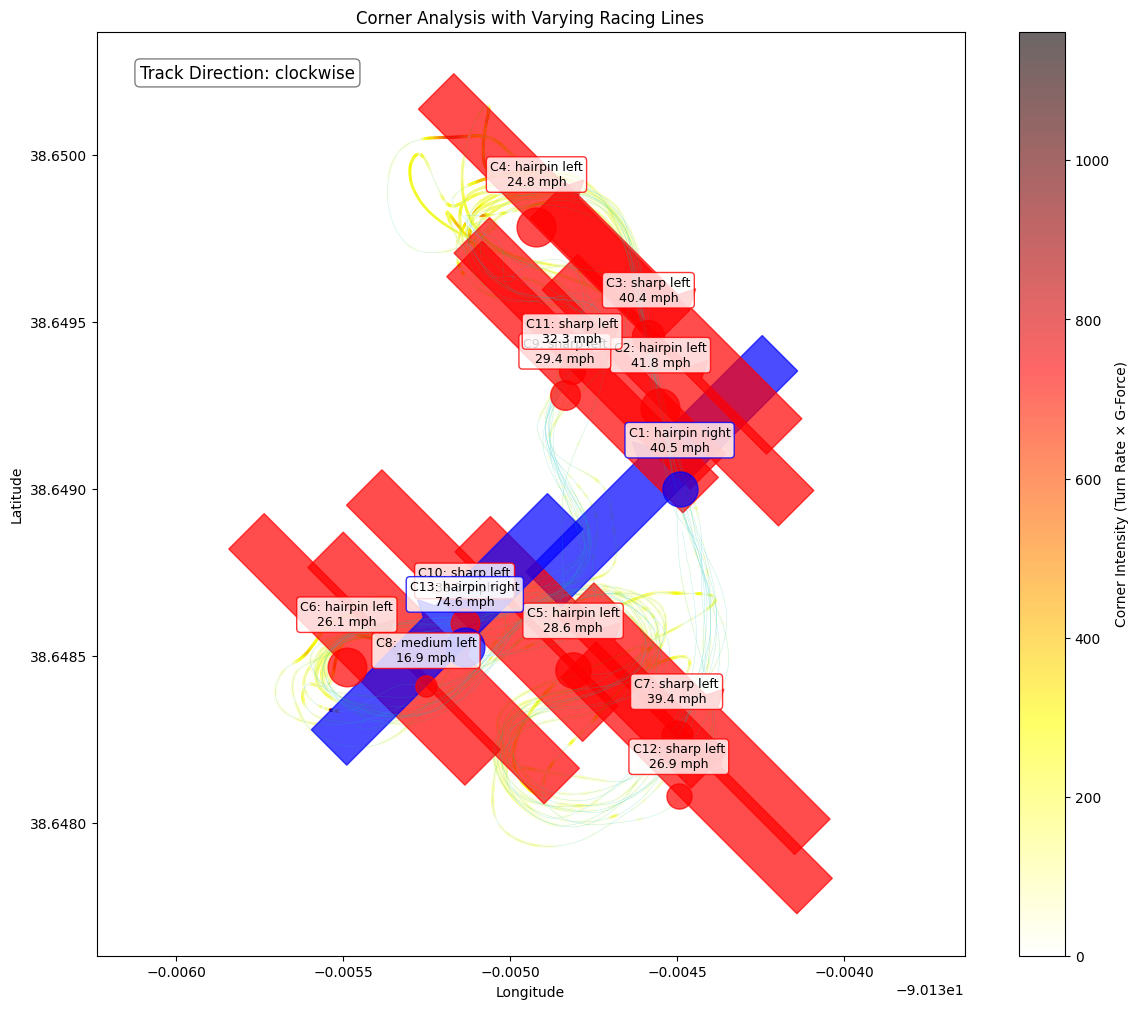

KeyboardInterrupt: 

In [ ]:
# After processing telemetry data
corners = identify_corners_from_aggregate_telemetry(filtered_df, min_cluster_size=8)

# Create corner visualization with heat map
corner_fig = visualize_corners_with_heatmap(filtered_df, corners)
plt.savefig('corner_analysis.png', dpi=300)
plt.show()

# Analyze how consistently you're taking each corner (learning progress)
consistency_df = analyze_corner_consistency(filtered_df, corners)
print("Corner Consistency Analysis:")
print(consistency_df[['corner_type', 'direction', 'speed_consistency', 'line_consistency', 'speed_trend']])

# Find corners where you're improving the most
improving_corners = consistency_df[consistency_df['speed_trend'] > 0.5]
if not improving_corners.empty:
    print("\nCorners with most improvement:")
    print(improving_corners[['corner_type', 'direction', 'min_speed', 'max_speed', 'speed_trend']])

# Find corners where you're most inconsistent (need more practice)
inconsistent_corners = consistency_df[consistency_df['line_consistency'] > consistency_df['line_consistency'].median()]
if not inconsistent_corners.empty:
    print("\nCorners with most inconsistent lines (need practice):")
    print(inconsistent_corners[['corner_type', 'direction', 'speed_consistency', 'line_consistency']])

In [ ]:
def visualize_corners_with_track(telemetry_df, corners, background_image_path=None):
    """
    Create a proper visualization of the track with detected corners
    that maintains the correct aspect ratio and uses UTM coordinates.
    """
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.image as mpimg
    
    # Set up figure with correct aspect ratio
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Create custom heat map colormap
    heat_colors = [(1,1,1,0), (1,1,0,0.3), (1,0.5,0,0.5), (1,0,0,0.7)]
    custom_cmap = LinearSegmentedColormap.from_list('corner_intensity', heat_colors)
    
    # If we have a background satellite image, display it first
    if background_image_path and os.path.exists(background_image_path):
        img = mpimg.imread(background_image_path)
        
        # You'll need to define these coordinates based on your image
        img_extent = [
            telemetry_df['longitude'].min() - 0.0001,
            telemetry_df['longitude'].max() + 0.0001,
            telemetry_df['latitude'].min() - 0.0001, 
            telemetry_df['latitude'].max() + 0.0001
        ]
        ax.imshow(img, extent=img_extent, aspect='equal', alpha=0.7)
    
    # 1. Plot the track traces (all laps) as thin light lines
    for lap in sorted(telemetry_df['lap'].unique()):
        lap_data = telemetry_df[telemetry_df['lap'] == lap]
        if len(lap_data) > 10:
            ax.plot(
                lap_data['longitude'], 
                lap_data['latitude'], 
                '-', 
                linewidth=0.7, 
                color='cyan' if lap_data['lap_name'].iloc[0] == 'timed' else 'lightgray',
                alpha=0.5
            )
    
    # 2. Create a heat map of cornering intensity (use Turn Rate × G-Force)
    corner_intensity = telemetry_df['turn_rate'].abs() * telemetry_df['g_force'] * 100
    
    # Filter to only show high-intensity cornering zones
    corner_points = telemetry_df[corner_intensity > 80]
    
    if len(corner_points) > 0:
        sc = ax.scatter(
            corner_points['longitude'],
            corner_points['latitude'],
            c=corner_points['turn_rate'].abs() * corner_points['g_force'] * 100,
            cmap=custom_cmap,
            s=15,
            alpha=0.6,
            vmin=0,
            vmax=1000
        )
        cbar = plt.colorbar(sc)
        cbar.set_label('Corner Intensity')
    
    # 3. Plot detected corners with proper labels
    corner_shown = set()  # To avoid duplicate corner labels
    
    # Function to calculate distance between corners
    def corner_distance(c1, c2):
        return c1.distance(c2) * 111000  # Approx meters
    
    # Group nearby corners (likely duplicates) - simplistic approach
    unique_corners = {}
    corner_groups = []
    
    # Group corners that are very close to each other
    for num1, corner1 in corners.items():
        center1 = corner1['center']
        found_group = False
        
        for group in corner_groups:
            for num2 in group:
                center2 = corners[num2]['center']
                if corner_distance(center1, center2) < 10:  # Within 10 meters
                    group.add(num1)
                    found_group = True
                    break
            if found_group:
                break
                
        if not found_group:
            corner_groups.append({num1})
    
    # Select representative corner from each group (highest severity)
    for group in corner_groups:
        best_corner = max(group, key=lambda x: corners[x]['severity'])
        unique_corners[best_corner] = corners[best_corner]
    
    # Plot the unique corners
    for corner_num, corner_data in unique_corners.items():
        center = corner_data['center']
        direction = corner_data['direction']
        corner_type = corner_data['type']
        min_speed = corner_data['min_speed_mph']
        
        # Different colors for left/right corners
        color = 'red' if direction == 'left' else 'blue'
        
        # Size based on severity
        size = 150 if corner_type == 'hairpin' else 120 if corner_type == 'sharp' else 100
        
        # Plot corner marker
        ax.scatter(center.x, center.y, s=size, color=color, alpha=0.7, 
                  edgecolor='white', linewidth=1.5, zorder=10)
        
        # Add corner label with information
        label = f"C{corner_num}: {corner_type} {direction}\n{min_speed:.1f} mph"
        
        # Adjust label position based on corner type and track layout
        offset_x = 0
        offset_y = size/8
        
        bbox_props = {
            'boxstyle': 'round,pad=0.3', 
            'fc': 'white', 
            'ec': color, 
            'alpha': 0.8
        }
        
        ax.annotate(
            label,
            (center.x, center.y),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            ha='center',
            fontsize=9,
            bbox=bbox_props,
            zorder=11
        )
    
    # Add track direction indicator
    plt.annotate(
        'Track Direction: clockwise',
        xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
    )
    
    # Ensure proper aspect ratio and eliminate coordinate values
    ax.set_aspect('equal')
    
    # Remove axis ticks and use track-relevant labels instead
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add title and make it look nice
    plt.title('Gateway Corner Analysis', fontsize=16)
    
    # Add a legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='cyan', lw=2, label='Timed Laps'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Left Corner'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Right Corner')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Set tight layout
    plt.tight_layout()
    
    return fig

# Improved corner detection function to avoid duplicates
def detect_track_corners_improved(telemetry_df, min_cluster_size=15, eps_distance=0.00005):
    """
    Improved corner detection that better handles learning drivers
    with inconsistent lines and avoids duplicate corner detection
    """
    from sklearn.cluster import DBSCAN
    import numpy as np
    
    # Create a composite score for corner detection
    telemetry_df = telemetry_df.copy()
    
    # 1. Calculate corner metrics
    telemetry_df['abs_turn_rate'] = abs(telemetry_df['turn_rate'])
    telemetry_df['lateral_g'] = abs(telemetry_df['accel_lateral'] * scaling_factor)
    
    # 2. Calculate a corner score - high values mean more significant cornering
    telemetry_df['corner_score'] = (
        telemetry_df['abs_turn_rate'] / 10 +  
        telemetry_df['lateral_g'] * 3
    )
    
    # 3. Filter to likely corner points
    corner_threshold = np.percentile(telemetry_df['corner_score'], 85)  # Top 15% of points
    corner_candidates = telemetry_df[telemetry_df['corner_score'] > corner_threshold]
    
    if len(corner_candidates) < min_cluster_size:
        return {}  # Not enough data points
        
    # 4. Perform spatial clustering to identify distinct corners
    coords = corner_candidates[['latitude', 'longitude']].values
    
    # DBSCAN parameters:
    # eps - maximum distance between points (in coordinate units)
    # min_samples - minimum points to form a cluster
    clustering = DBSCAN(eps=eps_distance, min_samples=min_cluster_size).fit(coords)
    corner_candidates['cluster'] = clustering.labels_
    
    # 5. Process each cluster to identify and characterize corners
    corners = {}
    valid_clusters = sorted(list(set(corner_candidates['cluster'].unique()) - {-1}))
    
    for i, cluster_id in enumerate(valid_clusters):
        cluster_points = corner_candidates[corner_candidates['cluster'] == cluster_id]
        
        # Skip small clusters
        if len(cluster_points) < min_cluster_size:
            continue
            
        # Calculate cluster center weighted by corner intensity
        weights = cluster_points['corner_score']
        avg_lat = np.average(cluster_points['latitude'], weights=weights)
        avg_lon = np.average(cluster_points['longitude'], weights=weights)
        
        # Determine the primary direction of the corner
        avg_turn_rate = np.median(cluster_points['turn_rate'])
        direction = 'left' if avg_turn_rate > 0 else 'right'
        
        # Calculate corner severity based on multiple metrics
        turn_rate_severity = np.percentile(abs(cluster_points['turn_rate']), 85)
        g_force_severity = np.percentile(cluster_points['g_force'], 85)
        speed_drop = np.percentile(cluster_points['speed_mph'], 85) - np.percentile(cluster_points['speed_mph'], 15)
        
        # Combined severity score
        severity = (turn_rate_severity/10) + (g_force_severity*5) + (speed_drop/5)
        
        # Categorize corner type based on severity
        if severity > 8:
            corner_type = 'hairpin'
        elif severity > 5:
            corner_type = 'sharp'
        elif severity > 3:
            corner_type = 'medium'
        else:
            corner_type = 'gentle'
            
        # Record corner information
        corners[i+1] = {
            'center': Point(avg_lon, avg_lat),
            'direction': direction,
            'severity': severity,
            'type': corner_type,
            'min_speed_mph': round(np.percentile(cluster_points['speed_mph'], 20), 1),
            'points_count': len(cluster_points)
        }
    
    return corners

/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_45216/2521477359.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corner_candidates['cluster'] = clustering.labels_


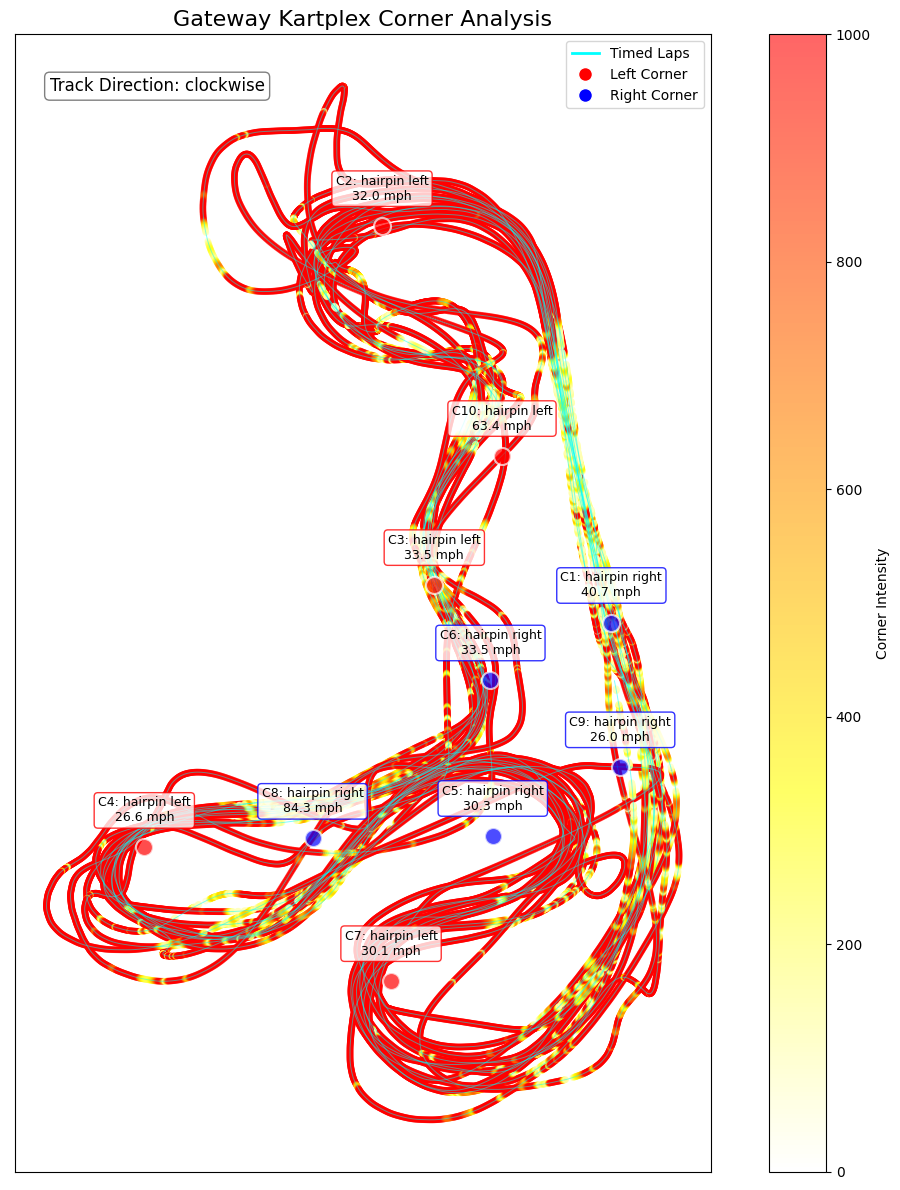

In [ ]:
# First, detect corners with improved algorithm
improved_corners = detect_track_corners_improved(
    filtered_df, 
    min_cluster_size=15,  # Adjust as needed
    eps_distance=0.00005  # Adjust for your GPS precision
)

# Create a better visualization
fig = visualize_corners_with_track(
    filtered_df, 
    improved_corners,
    background_image_path=None  # Add path to satellite image if available
)

# Save high resolution version
plt.savefig('gateway_corners_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# Combined with additional labels

In [ ]:
db_collection = [
    {"filename": './700_IL-203_S-2025-10-16_22-04-11.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 5},
    {"filename": './700_IL-203_S-2025-10-16_22-31-59.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 6},
    {"filename": './700_IL-203_S-2025-10-16_22-50-34.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 7},
]

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce

# --- Configuration ---
db_collection = [
    {"filename": './700_IL-203_S-2025-10-16_22-04-11.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 5},
    {"filename": './700_IL-203_S-2025-10-16_22-31-59.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 6},
    {"filename": './700_IL-203_S-2025-10-16_22-50-34.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway", 
     "visit": 2,
     "race": 7},
]

combined_telemetry_csv = './combined_telemetry.csv'  # output file for all data
scaling_factor = 0.3  # G-force scaling factor for karting
MPS_TO_MPH = 2.23694  # Meters per second to Miles per hour conversion factor

# Define start/finish and sector boundary lines
sf_line = LineString([(38.64886, -90.13461), (38.64888, -90.13440)])
s1_s2_line = LineString([(38.64918, -90.13474), (38.64911, -90.13491)])
s2_s3_line = LineString([(38.64868, -90.13454), (38.64852, -90.13473)])

# Define corners
# (can be added later if needed)

# Helper functions for data processing
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lat) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

# Create empty list to store all telemetry dataframes
all_telemetry_dfs = []

# Process each database in the collection
for race_index, race_info in enumerate(db_collection):
    db_path = race_info["filename"]
    race_id = race_index + 1  # Assign sequential race IDs for internal tracking
    proskill = race_info["proskill"]
    circuit = race_info["circuit"]
    race = race_info["race"]
    visit = race_info["visit"]
    
    print(f"\n\n--- Processing race {race_id}: {os.path.basename(db_path)} ---")

    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)
        
        # Read Location (GPS) data
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location", conn)
        
        # Read all sensor data and prepare for merge
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []
        
        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)
        
        # Merge all sensor dataframes on a common timestamp
        main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        
        conn.close()
        
        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion: {e}")
        if 'conn' in locals():
            conn.close()
        continue  # Skip to next database if there's an error

    # --- Clean GPS data ---
    print("Cleaning GPS data...")
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > 50:
            anomaly_indices.append(i)
    if anomaly_indices:
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
    gps_df['altitude'] = 0.0

    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")
    
    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    dt = np.mean(np.diff(imu_time))

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    for i in range(1, len(imu_time)):
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
        imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
        heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    fused_x = butter_lowpass_filter(fused_x, cutoff=3, fs=100) # was 5
    fused_y = butter_lowpass_filter(fused_y, cutoff=3, fs=100) # was 5
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=3, fs=100) # was 5
    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race_id'] = race_id  # Internal race ID
    
    # Add the new columns from race_info
    telemetry_df['proskill'] = proskill
    telemetry_df['circuit'] = circuit
    telemetry_df['race'] = race
    telemetry_df['visit'] = visit

    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        if segment.intersects(sf_line):
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    def get_lap_name(lap_num):
        if lap_num == 0: return 'out'
        elif lap_num == 1: return 'warm-up'
        elif lap_num == total_laps: return 'exit'
        else: return 'timed'
    telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

    # Sector Segmentation (continuing)
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        
        # Check for sector boundary crossings
        if i > 0:  # Ensure we have a previous point
            if sector_number == 1 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(s1_s2_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 1)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 2
            elif sector_number == 2 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(s2_s3_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 2)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 3
            elif sector_number == 3 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(sf_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 3)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 1

        telemetry_df.loc[i, 'sector'] = sector_number
        prev_point = current_point

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    
    # Only continue processing if there are timed laps
    if not filtered_df.empty:
        filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
        start_time = filtered_df['race_seconds_elapsed'].iloc[0]
        filtered_df['race_seconds_elapsed'] -= start_time
        filtered_df['lap_seconds_elapsed'] = 0.0
        
        for lap_num in filtered_df['lap'].unique():
            lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
            if not lap_indices.empty:
                lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
                filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

        # Calculate G-force and smooth
        filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + 
                                        (filtered_df['accel_longitudinal'] * scaling_factor)**2)
        window_size = 7
        filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
        upper_limit = filtered_df['g_force'].quantile(0.98)
        filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
        filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

        # --- Final Rounding and Conversion Step ---
        print("\n--- Final Rounding and Conversion ---")

        # CONVERSION: Speed (m/s) to Speed (mph)
        filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

        # Round time-based columns to 2 decimal places (100 Hz precision)
        filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
        filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
        filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

        # Round derived kinematics for readability
        filtered_df['speed'] = filtered_df['speed'].round(2)
        filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1) # Round mph to 1 decimal place
        filtered_df['bearing'] = filtered_df['bearing'].round(1)
        filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
        filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
        filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
        filtered_df['g_force'] = filtered_df['g_force'].round(2)
        filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

        # Round raw sensor data for readability (using defensive column checks)
        for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                    'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                    'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                    'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
            if col in filtered_df.columns:
                filtered_df[col] = filtered_df[col].round(4)

        # Add this dataset to our collection
        all_telemetry_dfs.append(filtered_df)
        
        print(f"Successfully processed race {race_id}: {os.path.basename(db_path)}")
    else:
        print(f"Warning: No timed laps found in race {race_id}: {os.path.basename(db_path)}")

# --- Combine all dataframes ---
print("\n--- Combining all telemetry data ---")
if all_telemetry_dfs:
    # Combine all dataframes into one
    combined_df = pd.concat(all_telemetry_dfs, ignore_index=True)
    
    # Reorder columns to put metadata first
    metadata_cols = ['race_id', 'proskill', 'circuit', 'race', 'visit', 'lap', 'lap_name', 'sector']
    # Get all columns that aren't metadata
    other_cols = [col for col in combined_df.columns if col not in metadata_cols]
    # Rearrange columns
    combined_df = combined_df[metadata_cols + other_cols]
    
    # Save the combined data to CSV
    combined_df.to_csv(combined_telemetry_csv, index=False)
    print(f'Combined telemetry data from {len(all_telemetry_dfs)} races saved to {combined_telemetry_csv}')
    
    # Output some basic statistics
    print(f"\nTotal rows in combined dataset: {len(combined_df)}")
    print(f"Races included: {combined_df['race_id'].nunique()}")
    print(f"Timed laps included: {len(combined_df)}")
    
    # Show some info about each race processed
    for race_id in combined_df['race_id'].unique():
        race_data = combined_df[combined_df['race_id'] == race_id]
        race_info = db_collection[race_id-1]  # -1 because race_id starts from 1
        print(f"\nRace {race_id} ({race_info['circuit']}, Visit {race_info['visit']}, Race {race_info['race']}):")
        print(f"  Laps: {race_data['lap'].nunique()}")
        print(f"  Data points: {len(race_data)}")
else:
    print("No valid telemetry data was processed. Check your database files and configurations.")




--- Processing race 1: 700_IL-203_S-2025-10-16_22-04-11.sqlite ---
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---

--- Final Rounding and Conversion ---
Successfully processed race 1: 700_IL-203_S-2025-10-16_22-04-11.sqlite


--- Processing race 2: 700_IL-203_S-2025-10-16_22-31-59.sqlite ---
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---

--- Final Rounding and Conversion ---
Successfully processed race 2: 700_IL-203_S-2025-10-16_22-31-59.sqlite


--- Processing race 3: 700_IL-203_S-2025-10-16_22-50-34.sqlite ---
--- Step 1:

# Load, label, merge

In [ ]:
# what to load

db_collection = [
    {"filename": './gateway-1.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 1,
     "race": 1},
    {"filename": './gateway-2.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 1,
     "race": 2},
    {"filename": './gateway-3.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 1,
     "race": 3},        
    {"filename": './gateway-4.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 1,
     "race": 4},    
    {"filename": './700_IL-203_S-2025-10-16_22-04-11.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 2,
     "race": 7},
    {"filename": './700_IL-203_S-2025-10-16_22-31-59.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 2,
     "race": 6},
    {"filename": './700_IL-203_S-2025-10-16_22-50-34.sqlite', 
     "proskill": "Pro", 
     "circuit": "Gateway Kartplex", 
     "visit": 2,
     "race": 5},
]

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce
import json

combined_telemetry_csv = './combined_telemetry.csv'  # output file for all data
scaling_factor = 0.3  # G-force scaling factor for karting
MPS_TO_MPH = 2.23694  # Meters per second to Miles per hour conversion factor

# Load circuit data from GeoJSON file
try:
    with open('./Gateway/circuit.geojson', 'r') as f:
        circuit_data = json.load(f)
    
    # Extract segment lines from GeoJSON
    segment_lines = {}
    segment_properties = {}
    
    for feature in circuit_data['features']:
        if feature['geometry']['type'] == 'LineString':
            segment_id = feature['properties'].get('Segment')
            if segment_id is not None:
                coords = feature['geometry']['coordinates']
                # Convert to Shapely LineString with coords in lat, lon order (reversed from GeoJSON)
                line = LineString([(coords[0][1], coords[0][0]), (coords[1][1], coords[1][0])])
                segment_lines[segment_id] = line
                segment_properties[segment_id] = feature['properties']
    
    print(f"Loaded {len(segment_lines)} track segments from GeoJSON")
    
    # Find start/finish line and sector boundaries
    sf_line = None
    s1_s2_line = None
    s2_s3_line = None
    
    for segment_id, props in segment_properties.items():
        if props.get('Landmark') == 'StartStop' or (props.get('Sector') == 1 and segment_id == 1):
            sf_line = segment_lines[segment_id]
            print(f"Found Start/Finish line (Segment {segment_id})")
        elif props.get('Sector') == 2:
            s1_s2_line = segment_lines[segment_id]
            print(f"Found Sector 1/2 boundary (Segment {segment_id})")
        elif props.get('Sector') == 3:
            s2_s3_line = segment_lines[segment_id]
            print(f"Found Sector 2/3 boundary (Segment {segment_id})")
    
    # Fallback if sectors not properly defined in GeoJSON
    if sf_line is None:
        sf_line = LineString([(38.64886, -90.13461), (38.64888, -90.13440)])
        print("Warning: Using hardcoded Start/Finish line")
    if s1_s2_line is None:
        s1_s2_line = LineString([(38.64918, -90.13474), (38.64911, -90.13491)])
        print("Warning: Using hardcoded Sector 1/2 boundary")
    if s2_s3_line is None:
        s2_s3_line = LineString([(38.64868, -90.13454), (38.64852, -90.13473)])
        print("Warning: Using hardcoded Sector 2/3 boundary")

except Exception as e:
    print(f"Error loading circuit data: {e}")
    # Fallback to hardcoded values
    sf_line = LineString([(38.64886, -90.13461), (38.64888, -90.13440)])
    s1_s2_line = LineString([(38.64918, -90.13474), (38.64911, -90.13491)])
    s2_s3_line = LineString([(38.64868, -90.13454), (38.64852, -90.13473)])
    segment_lines = {}
    segment_properties = {}

# Helper functions for data processing
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lat) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

# Function to detect segment crossings
def detect_segment(point1, point2):
    """Detect which segment line is crossed by the line between point1 and point2"""
    movement_line = LineString([point1, point2])
    crossed_segments = []
    
    for segment_id, segment_line in segment_lines.items():
        if movement_line.intersects(segment_line):
            crossed_segments.append(segment_id)
            
    return crossed_segments if crossed_segments else None

# Create empty list to store all telemetry dataframes
all_telemetry_dfs = []

# Process each database in the collection
for race_index, race_info in enumerate(db_collection):
    db_path = race_info["filename"]
    race_id = race_index + 1  # Assign sequential race IDs for internal tracking
    proskill = race_info["proskill"]
    circuit = race_info["circuit"]
    race = race_info["race"]
    visit = race_info["visit"]
    
    print(f"\n\n--- Processing race {race_id}: {os.path.basename(db_path)} ---")

    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)
        
        # Read Location (GPS) data
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location", conn)
        
        # Read all sensor data and prepare for merge
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []
        
        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)
        
        # Merge all sensor dataframes on a common timestamp
        main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        
        conn.close()
        
        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion: {e}")
        if 'conn' in locals():
            conn.close()
        continue  # Skip to next database if there's an error

    # --- Clean GPS data ---
    print("Cleaning GPS data...")
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > 50:
            anomaly_indices.append(i)
    if anomaly_indices:
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
    gps_df['altitude'] = 0.0

    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")
    
    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    dt = np.mean(np.diff(imu_time))

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    for i in range(1, len(imu_time)):
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
        imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
        heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    fused_x = butter_lowpass_filter(fused_x, cutoff=3, fs=100) # was 5
    fused_y = butter_lowpass_filter(fused_y, cutoff=3, fs=100) # was 5
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])


    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=3, fs=100) # was 5
    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race_id'] = race_id  # Internal race ID
    
    # Add the new columns from race_info
    telemetry_df['proskill'] = proskill
    telemetry_df['circuit'] = circuit
    telemetry_df['race'] = race
    telemetry_df['visit'] = visit

    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        if segment.intersects(sf_line):
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    def get_lap_name(lap_num):
        if lap_num == 0: return 'out'
        elif lap_num == 1: return 'warm-up'
        elif lap_num == total_laps: return 'exit'
        else: return 'timed'
    telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

# --- Segment Detection (improved with sequential logic) ---
print("Detecting track segments...")
telemetry_df['segment'] = 0
prev_point = None

# First pass: Identify segment crossings
segment_crossings = []
for i, row in telemetry_df.iterrows():
    current_point = Point(row['latitude'], row['longitude'])
    if prev_point is not None:
        movement_line = LineString([prev_point, current_point])
        for segment_id, segment_line in segment_lines.items():
            if movement_line.intersects(segment_line):
                segment_crossings.append((i, segment_id))
    prev_point = current_point

# Sort crossings by index to ensure correct sequence
segment_crossings.sort(key=lambda x: x[0])

# Second pass: Apply sequential segment logic
current_segment = 0
expected_next_segment = 1
last_segment_idx = -1

# Create dictionary to store clean segment assignments
clean_segments = {}

for idx, segment_id in segment_crossings:
    # Check if this is the expected next segment
    if segment_id == expected_next_segment:
        current_segment = segment_id
        clean_segments[idx] = current_segment
        
        # Update expected next segment (wrapping around at max segment)
        expected_next_segment = segment_id + 1
        if expected_next_segment > len(segment_lines):
            expected_next_segment = 1
            
        last_segment_idx = idx
    # If we encounter the first segment again (completing a lap)
    elif segment_id == 1 and current_segment > 0:
        current_segment = 1
        clean_segments[idx] = current_segment
        expected_next_segment = 2
        last_segment_idx = idx
    # Skip anomalies (unexpected segment crossings)
    else:
        print(f"Skipping anomalous segment crossing: expected {expected_next_segment}, found {segment_id} at idx {idx}")

# Apply clean segments to the dataframe
for idx, segment_id in clean_segments.items():
    telemetry_df.loc[idx, 'segment'] = segment_id

# Forward fill segments (between crossing points)
if not telemetry_df.empty:
    # Forward fill segment information
    telemetry_df['segment'] = telemetry_df['segment'].replace(0, np.nan).ffill().fillna(0).astype(int)

# Print segment statistics
segment_counts = telemetry_df['segment'].value_counts().sort_index()
print(f"Track segments detected: {telemetry_df['segment'].nunique() - (1 if 0 in telemetry_df['segment'].unique() else 0)}")
print("Segment distribution:")
for seg_id, count in segment_counts.items():
    if seg_id > 0:  # Skip segment 0 (unassigned)
        print(f"  Segment {seg_id}: {count} data points")

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

    # Sector Segmentation (continuing)
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        
        # Check for sector boundary crossings
        if i > 0:  # Ensure we have a previous point
            if sector_number == 1 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(s1_s2_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 1)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 2
            elif sector_number == 2 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(s2_s3_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 2)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 3
            elif sector_number == 3 and LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point]).intersects(sf_line):
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                telemetry_df.loc[telemetry_df['lap'] == row['lap'], 'sector_time'] = sector_duration
                sector_times[(row['lap'], 3)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 1

        telemetry_df.loc[i, 'sector'] = sector_number
        prev_point = current_point

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    
    # Only continue processing if there are timed laps
    if not filtered_df.empty:
        filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
        start_time = filtered_df['race_seconds_elapsed'].iloc[0]
        filtered_df['race_seconds_elapsed'] -= start_time
        filtered_df['lap_seconds_elapsed'] = 0.0
        
        for lap_num in filtered_df['lap'].unique():
            lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
            if not lap_indices.empty:
                lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
                filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

        # Calculate G-force and smooth
        filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + 
                                        (filtered_df['accel_longitudinal'] * scaling_factor)**2)
        window_size = 7
        filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
        upper_limit = filtered_df['g_force'].quantile(0.98)
        filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
        filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

        # --- Final Rounding and Conversion Step ---
        print("\n--- Final Rounding and Conversion ---")

        # CONVERSION: Speed (m/s) to Speed (mph)
        filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

        # Round time-based columns to 2 decimal places (100 Hz precision)
        filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
        filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
        filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

        # Round derived kinematics for readability
        filtered_df['speed'] = filtered_df['speed'].round(2)
        filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1) # Round mph to 1 decimal place
        filtered_df['bearing'] = filtered_df['bearing'].round(1)
        filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
        filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
        filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
        filtered_df['g_force'] = filtered_df['g_force'].round(2)
        filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

        # Round raw sensor data for readability (using defensive column checks)
        for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                    'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                    'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                    'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
            if col in filtered_df.columns:
                filtered_df[col] = filtered_df[col].round(4)

        # Add this dataset to our collection
        all_telemetry_dfs.append(filtered_df)
        
        # Print segment statistics
        print(f"Track segments detected: {filtered_df['segment'].nunique()}")
        segment_counts = filtered_df['segment'].value_counts().sort_index()
        print("Segment distribution:")
        for seg_id, count in segment_counts.items():
            if seg_id > 0:  # Skip segment 0 (unassigned)
                print(f"  Segment {seg_id}: {count} data points")
        
        print(f"Successfully processed race {race_id}: {os.path.basename(db_path)}")
    else:
        print(f"Warning: No timed laps found in race {race_id}: {os.path.basename(db_path)}")

# --- Combine all dataframes ---
print("\n--- Combining all telemetry data ---")
if all_telemetry_dfs:
    # Combine all dataframes into one
    combined_df = pd.concat(all_telemetry_dfs, ignore_index=True)
    
    # Reorder columns to put metadata first
    metadata_cols = ['race_id', 'proskill', 'circuit', 'race', 'visit', 'lap', 'lap_name', 'sector', 'segment']
    # Add any segment property columns
    segment_prop_cols = [col for col in combined_df.columns if col.startswith('segment_')]
    metadata_cols.extend(segment_prop_cols)
    
    # Get all columns that aren't metadata
    other_cols = [col for col in combined_df.columns if col not in metadata_cols]
    # Rearrange columns
    combined_df = combined_df[metadata_cols + other_cols]
    
    # Save the combined data to CSV
    combined_df.to_csv(combined_telemetry_csv, index=False)
    print(f'Combined telemetry data from {len(all_telemetry_dfs)} races saved to {combined_telemetry_csv}')
    
    # Output some basic statistics
    print(f"\nTotal rows in combined dataset: {len(combined_df)}")
    print(f"Races included: {combined_df['race_id'].nunique()}")
    print(f"Timed laps included: {len(combined_df)}")
    print(f"Track segments detected: {combined_df['segment'].nunique()}")
    
    # Show some info about each race processed
    for race_id in combined_df['race_id'].unique():
        race_data = combined_df[combined_df['race_id'] == race_id]
        race_info = db_collection[race_id-1]  # -1 because race_id starts from 1
        print(f"\nRace {race_id} ({race_info['circuit']}, Visit {race_info['visit']}, Race {race_info['race']}):")
        print(f"  Laps: {race_data['lap'].nunique()}")
        print(f"  Data points: {len(race_data)}")
        print(f"  Segments detected: {race_data['segment'].nunique()}")
else:
    print("No valid telemetry data was processed. Check your database files and configurations.")


Error loading circuit data: [Errno 2] No such file or directory: './Gateway/circuit.geojson'


--- Processing race 1: gateway-1.sqlite ---
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---


--- Processing race 2: gateway-2.sqlite ---
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---


--- Processing race 3: gateway-3.sqlite ---
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sen

In [ ]:
# config info about the circuit, metadata, etc.
race_config = [
    {
        "filename": "./gateway-1.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 1,
        "race": 1
    },
    {
        "filename": "./gateway-2.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 1,
        "race": 2
    },
    {
        "filename": "./gateway-3.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 1,
        "race": 3
    },
    {
        "filename": "./gateway-4.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 1,
        "race": 4
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-04-11.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 2,
        "race": 5
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-31-59.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 2,
        "race": 6
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-50-34.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LineString([(38.64886, -90.13461), (38.64888, -90.13440)])",
        "s1_s2_line": "LineString([(38.64918, -90.13474), (38.64911, -90.13491)])",
        "s2_s3_line": "LineString([(38.64868, -90.13454), (38.64852, -90.13473)])",
        "visit": 2,
        "race": 7
    }
]


In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce
from shapely.wkt import loads # Import loads explicitly for WKT parsing

# The race_config list is defined here, containing the configuration for all races.
race_config = [
    {
        "filename": "./gateway-1.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 1
    },
    {
        "filename": "./gateway-2.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 2
    },
    {
        "filename": "./gateway-3.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 3
    },
    {
        "filename": "./gateway-4.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 4
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-04-11.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 5
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-31-59.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 6
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-50-34.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 7
    }
]

# Helper function to safely evaluate LineString from string
def parse_linestring(s):
    return loads(s)

# --- Define common constants/functions outside the loop ---

scaling_factor = 0.3 # G-force scaling factor for karting
MPS_TO_MPH = 2.23694 # Meters per second to Miles per hour conversion factor

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lon) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

def get_lap_name(lap_num, max_laps):
    if max_laps == 0 or lap_num == 0: return 'out'
    elif lap_num == 1: return 'warm-up'
    elif lap_num == max_laps: return 'exit'
    else: return 'timed'

def check_and_update_sector(segment, sf_line, s1_s2_line, s2_s3_line, 
                            current_lap, current_sector, sector_start_time, row_time):
    """Checks for sector crossing and returns updated sector, start time, and success flag."""
    
    line_to_check = None
    next_sector_num = current_sector
    
    # Determine which line we expect to cross to advance the sector
    if current_sector == 1:
        line_to_check = s1_s2_line
        next_sector_num = 2
    elif current_sector == 2:
        line_to_check = s2_s3_line
        next_sector_num = 3
    elif current_sector == 3:
        line_to_check = sf_line
        next_sector_num = 1 # SF line marks the start of the next sector 1

    if current_lap > 0 and line_to_check and segment.intersects(line_to_check):
        # Crossing detected: time the completed sector and move to the next
        return next_sector_num, row_time, True
    
    return current_sector, sector_start_time, False # No crossing, return original values


# --- Main Processing Loop ---

for config in race_config:
    # --- Configuration for current race ---
    db_path = config['filename']
    telemetry_csv = db_path.replace('.sqlite', '.telemetry.csv') # Dynamically create output filename
    race_id = config['race']

    # Define start/finish and sector boundary lines from config
    try:
        sf_line = parse_linestring(config['sf_line'])
        s1_s2_line = parse_linestring(config['s1_s2_line'])
        s2_s3_line = parse_linestring(config['s2_s3_line'])
    except Exception as e:
        print(f"Error parsing LineString for race {race_id}: {e}. Skipping.")
        continue


    print(f"\n=================================================================")
    print(f"Processing Race {race_id}: {db_path}")
    print(f"=================================================================")

    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)

        # Read Location (GPS) data
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location", conn)

        # Read all sensor data and prepare for merge
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []

        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)

        # Merge all sensor dataframes on a common timestamp
        if list_of_dfs:
            main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        else:
            print("Warning: No sensor data tables found. Continuing with only GPS data.")
            main_df = gps_df[['time', 'seconds_elapsed', 'utc_time']].drop_duplicates().sort_values('seconds_elapsed')
            
        conn.close()

        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion for race {race_id}: {e}. Skipping this race.")
        if 'conn' in locals():
            conn.close()
        continue

    # --- Clean GPS data ---
    print("Cleaning GPS data...")
    if gps_df.empty:
        print(f"Error: GPS data is empty for race {race_id}. Skipping.")
        continue
        
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > 50: # Simple speed outlier detection (50 m/s ~ 111 mph)
            anomaly_indices.append(i)
    if anomaly_indices:
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
        print(f"Dropped {len(anomaly_indices)} GPS anomalies.")
    gps_df['altitude'] = 0.0

    # Ensure main_df has the same time base as the cleaned GPS data for common time steps
    main_df = pd.merge(main_df, gps_df[['seconds_elapsed']], on='seconds_elapsed', how='inner')
    main_df = main_df.sort_values('seconds_elapsed').reset_index(drop=True)
    
    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")

    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    if len(imu_time) < 2:
        print(f"Error: Insufficient data points for race {race_id}. Skipping.")
        continue

    dt = np.mean(np.diff(imu_time)) if len(imu_time) > 1 else 0.01

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0] if len(computed_bearing) > 0 else 0], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    
    # Heading fusion using Gyroscope_z
    if 'Gyroscope_z' in main_df.columns:
        gyro_z_values = main_df['Gyroscope_z'].values
        for i in range(1, len(imu_time)):
            gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
            time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
            blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
            imu_heading_change = gyro_z_values[i] * dt * 57.2958 # Convert rad/s to deg
            heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)
    else:
        print("Warning: Gyroscope_z data missing. Using only interpolated GPS bearing for heading.")
        heading = base_heading


    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    # Low-pass filter final positions
    fs = 1.0 / dt if dt > 0 else 100
    fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=fs)
    fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=fs)
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    # Recalculate kinematics from fused position
    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0] if len(fused_speed) > 0 else 0], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=fs)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0] if len(fused_bearing) > 0 else 0], fused_bearing])
    
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    
    turn_rate = np.zeros_like(imu_time)
    if 'Gyroscope_z' in main_df.columns:
        turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=fs)
    else:
        # Fallback for turn rate if gyro data is missing
        bearing_change = np.diff(fused_bearing)
        bearing_change = np.where(bearing_change > 180, bearing_change - 360, bearing_change)
        bearing_change = np.where(bearing_change < -180, bearing_change + 360, bearing_change)
        turn_rate_calc = bearing_change / dt
        turn_rate = np.concatenate([[turn_rate_calc[0] if len(turn_rate_calc) > 0 else 0], turn_rate_calc])
        print("Warning: Gyroscope_z missing. Using calculated turn rate from bearing.")

    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race'] = race_id
    telemetry_df['race_date'] = config['race_date']
    telemetry_df['circuit'] = config['circuit']
    telemetry_df['visit'] = config['visit']


    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        # Only increment lap if segment crosses SF line
        if segment.intersects(sf_line):
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    telemetry_df['lap_name'] = telemetry_df['lap'].apply(lambda x: get_lap_name(x, total_laps))
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    prev_lap = telemetry_df['lap'].iloc[0] if not telemetry_df.empty else 0
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0] if not telemetry_df.empty else 0

    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        current_lap = row['lap']
        current_time = row['seconds_elapsed']
        
        # Reset sector counter when lap changes *and* we enter the main part of the lap (lap > 0)
        if prev_lap != current_lap and current_lap > 0:
            sector_number = 1
            sector_start_time = current_time
        
        if i > 0:
            segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
            
            # Call the new global helper function, which returns the new state
            new_sector, new_start_time, crossed = check_and_update_sector(
                segment, sf_line, s1_s2_line, s2_s3_line,
                current_lap, sector_number, sector_start_time, current_time
            )

            if crossed:
                # If a crossing occurred, calculate duration for the sector just completed
                completed_sector = sector_number
                duration = new_start_time - sector_start_time 
                
                # Only record sector times for fully timed laps (lap > 0)
                if current_lap > 0:
                     sector_times[(current_lap, completed_sector)] = duration
                
                # Update loop variables
                sector_number = new_sector
                sector_start_time = new_start_time
                
        # Assign current sector number (0 for out/warm-up/exit laps, or the current sector 1, 2, or 3)
        telemetry_df.loc[i, 'sector'] = sector_number if current_lap > 0 else 0
        prev_point = current_point
        prev_lap = current_lap

    # Print diagnostics
    print(f"\nSector crossings detected for Race {race_id}:")
    for (lap, sector), time in sorted(sector_times.items()):
        print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    
    if filtered_df.empty:
        print(f"No 'timed' laps found for race {race_id}. Skipping final output.")
        continue
        
    filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
    
    start_time = filtered_df['race_seconds_elapsed'].iloc[0]
    filtered_df['race_seconds_elapsed'] -= start_time
    filtered_df['lap_seconds_elapsed'] = 0.0
    for lap_num in filtered_df['lap'].unique():
        lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
        if not lap_indices.empty:
            lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
            filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

    # Calculate G-force and smooth
    filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
    window_size = 7
    filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
    upper_limit = filtered_df['g_force'].quantile(0.98)
    filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

    # --- Final Rounding and Conversion Step ---
    print("\n--- Final Rounding and Conversion ---")

    # CONVERSION: Speed (m/s) to Speed (mph)
    filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

    # Rounding time-based columns
    filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
    filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
    # The 'sector_time' column is mostly NaN, this rounding is mostly for structure
    # filtered_df['sector_time'] = filtered_df['sector_time'].round(2) 

    # Rounding derived kinematics
    filtered_df['speed'] = filtered_df['speed'].round(2)
    filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1)
    filtered_df['bearing'] = filtered_df['bearing'].round(1)
    filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
    filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
    filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
    filtered_df['g_force'] = filtered_df['g_force'].round(2)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

    # Rounding raw sensor data (defensive checks included)
    for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
        if col in filtered_df.columns:
            filtered_df[col] = filtered_df[col].round(4)


    print(f"\nProcessing complete for Race {race_id}. Final data is in the `filtered_df` DataFrame.")

    # To save the final result to a CSV
    filtered_df.to_csv(telemetry_csv, index=False)
    print(f'Final telemetry data saved to {telemetry_csv}')

    # Save 10Hz version
    filtered_df_10hz = filtered_df.iloc[::10].copy()
    telemetry_csv_10hz = telemetry_csv.replace('.csv', '_10hz.csv')
    filtered_df_10hz.to_csv(telemetry_csv_10hz, index=False)
    print(f'10 Hz telemetry saved to {telemetry_csv_10hz}')

print("\nAll races in the configuration have been processed.")



Processing Race 1: ./gateway-1.sqlite
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---
Error: Insufficient data points for race 1. Skipping.

Processing Race 2: ./gateway-2.sqlite
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...
Dropped 1 GPS anomalies.

--- Step 2: Sensor Fusion & Enhancement ---
Error: Insufficient data points for race 2. Skipping.

Processing Race 3: ./gateway-3.sqlite
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...
Dropped 1 GPS anomalies.

--- Step 2: Sensor Fusion & Enhancement ---
Error: Insufficie

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce
from shapely.wkt import loads # Import loads explicitly for WKT parsing

# The race_config list is defined here, containing the configuration for all races.
race_config = [
    {
        "filename": "./gateway-1.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 1
    },
    {
        "filename": "./gateway-2.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 2
    },
    {
        "filename": "./gateway-3.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 3
    },
    {
        "filename": "./gateway-4.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 1,
        "race": 4
    },
    {
        "filename": "./data/700_IL-203_S-2025-10-16_22-04-11.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 5
    },
    {
        "filename": "./data/700_IL-203_S-2025-10-16_22-31-59.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 6
    },
    {
        "filename": "./data/700_IL-203_S-2025-10-16_22-50-34.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway Kartplex",
        "sf_line": "LINESTRING (38.64886 -90.13461, 38.64888 -90.13440)",
        "s1_s2_line": "LINESTRING (38.64918 -90.13474, 38.64911 -90.13491)",
        "s2_s3_line": "LINESTRING (38.64868 -90.13454, 38.64852 -90.13473)",
        "visit": 2,
        "race": 7
    }
]

# Helper function to safely evaluate LineString from string
def parse_linestring(s):
    return loads(s)

# --- Define common constants/functions outside the loop ---

scaling_factor = 0.3 # G-force scaling factor for karting
MPS_TO_MPH = 2.23694 # Meters per second to Miles per hour conversion factor

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lon) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

def get_lap_name(lap_num, max_laps):
    if max_laps == 0 or lap_num == 0: return 'out'
    elif lap_num == 1: return 'warm-up'
    elif lap_num == max_laps: return 'exit'
    else: return 'timed'

def check_and_update_sector(segment, sf_line, s1_s2_line, s2_s3_line, 
                            current_lap, current_sector, sector_start_time, row_time):
    """Checks for sector crossing and returns updated sector, start time, and success flag."""
    
    line_to_check = None
    next_sector_num = current_sector
    
    # Determine which line we expect to cross to advance the sector
    if current_sector == 1:
        line_to_check = s1_s2_line
        next_sector_num = 2
    elif current_sector == 2:
        line_to_check = s2_s3_line
        next_sector_num = 3
    elif current_sector == 3:
        line_to_check = sf_line
        next_sector_num = 1 # SF line marks the start of the next sector 1

    if current_lap > 0 and line_to_check and segment.intersects(line_to_check):
        # Crossing detected: time the completed sector and move to the next
        return next_sector_num, row_time, True
    
    return current_sector, sector_start_time, False # No crossing, return original values


# --- Main Processing Loop ---

for config in race_config:
    # --- Configuration for current race ---
    db_path = config['filename']
    telemetry_csv = db_path.replace('.sqlite', '.telemetry.csv') # Dynamically create output filename
    race_id = config['race']

    # Define start/finish and sector boundary lines from config
    try:
        sf_line = parse_linestring(config['sf_line'])
        s1_s2_line = parse_linestring(config['s1_s2_line'])
        s2_s3_line = parse_linestring(config['s2_s3_line'])
    except Exception as e:
        print(f"Error parsing LineString for race {race_id}: {e}. Skipping.")
        continue


    print(f"\n=================================================================")
    print(f"Processing Race {race_id}: {db_path}")
    print(f"=================================================================")

    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)

        # Read Location (GPS) data
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location", conn)

        # Read all sensor data and prepare for merge
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []

        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)

        # Merge all sensor dataframes on a common timestamp
        if list_of_dfs:
            main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        else:
            print("Warning: No sensor data tables found. Continuing with only GPS data.")
            main_df = gps_df[['time', 'seconds_elapsed', 'utc_time']].drop_duplicates().sort_values('seconds_elapsed')
            
        conn.close()

        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion for race {race_id}: {e}. Skipping this race.")
        if 'conn' in locals():
            conn.close()
        continue

    # --- Clean GPS data ---
    print("Cleaning GPS data...")
    if gps_df.empty:
        print(f"Error: GPS data is empty for race {race_id}. Skipping.")
        continue
        
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > 50: # Simple speed outlier detection (50 m/s ~ 111 mph)
            anomaly_indices.append(i)
    if anomaly_indices:
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
        print(f"Dropped {len(anomaly_indices)} GPS anomalies.")
    gps_df['altitude'] = 0.0

    # Ensure main_df has the same time base as the cleaned GPS data for common time steps
    main_df = pd.merge(main_df, gps_df[['seconds_elapsed']], on='seconds_elapsed', how='inner')
    main_df = main_df.sort_values('seconds_elapsed').reset_index(drop=True)
    
    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")

    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    if len(imu_time) < 2:
        print(f"Error: Insufficient data points for race {race_id}. Skipping.")
        continue

    dt = np.mean(np.diff(imu_time)) if len(imu_time) > 1 else 0.01

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0] if len(computed_bearing) > 0 else 0], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    
    # Heading fusion using Gyroscope_z
    if 'Gyroscope_z' in main_df.columns:
        gyro_z_values = main_df['Gyroscope_z'].values
        for i in range(1, len(imu_time)):
            gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
            time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
            blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
            imu_heading_change = gyro_z_values[i] * dt * 57.2958 # Convert rad/s to deg
            heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)
    else:
        print("Warning: Gyroscope_z data missing. Using only interpolated GPS bearing for heading.")
        heading = base_heading


    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    # Low-pass filter final positions
    fs = 1.0 / dt if dt > 0 else 100
    fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=fs)
    fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=fs)
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    # Recalculate kinematics from fused position
    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0] if len(fused_speed) > 0 else 0], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=fs)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0] if len(fused_bearing) > 0 else 0], fused_bearing])
    
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    
    turn_rate = np.zeros_like(imu_time)
    if 'Gyroscope_z' in main_df.columns:
        turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=fs)
    else:
        # Fallback for turn rate if gyro data is missing
        bearing_change = np.diff(fused_bearing)
        bearing_change = np.where(bearing_change > 180, bearing_change - 360, bearing_change)
        bearing_change = np.where(bearing_change < -180, bearing_change + 360, bearing_change)
        turn_rate_calc = bearing_change / dt
        turn_rate = np.concatenate([[turn_rate_calc[0] if len(turn_rate_calc) > 0 else 0], turn_rate_calc])
        print("Warning: Gyroscope_z missing. Using calculated turn rate from bearing.")

    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race'] = race_id
    telemetry_df['race_date'] = config['race_date']
    telemetry_df['circuit'] = config['circuit']
    telemetry_df['visit'] = config['visit']


    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        # Only increment lap if segment crosses SF line
        if segment.intersects(sf_line):
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    telemetry_df['lap_name'] = telemetry_df['lap'].apply(lambda x: get_lap_name(x, total_laps))
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    prev_lap = telemetry_df['lap'].iloc[0] if not telemetry_df.empty else 0
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0] if not telemetry_df.empty else 0

    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        current_lap = row['lap']
        current_time = row['seconds_elapsed']
        
        # Reset sector counter when lap changes *and* we enter the main part of the lap (lap > 0)
        if prev_lap != current_lap and current_lap > 0:
            sector_number = 1
            sector_start_time = current_time
        
        if i > 0:
            segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
            
            # Call the new global helper function, which returns the new state
            new_sector, new_start_time, crossed = check_and_update_sector(
                segment, sf_line, s1_s2_line, s2_s3_line,
                current_lap, sector_number, sector_start_time, current_time
            )

            if crossed:
                # If a crossing occurred, calculate duration for the sector just completed
                completed_sector = sector_number
                duration = new_start_time - sector_start_time 
                
                # Only record sector times for fully timed laps (lap > 0)
                if current_lap > 0:
                     sector_times[(current_lap, completed_sector)] = duration
                
                # Update loop variables
                sector_number = new_sector
                sector_start_time = new_start_time
                
        # Assign current sector number (0 for out/warm-up/exit laps, or the current sector 1, 2, or 3)
        telemetry_df.loc[i, 'sector'] = sector_number if current_lap > 0 else 0
        prev_point = current_point
        prev_lap = current_lap

    # Print diagnostics
    print(f"\nSector crossings detected for Race {race_id}:")
    for (lap, sector), time in sorted(sector_times.items()):
        print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    
    if filtered_df.empty:
        print(f"No 'timed' laps found for race {race_id}. Skipping final output.")
        continue
        
    filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
    
    start_time = filtered_df['race_seconds_elapsed'].iloc[0]
    filtered_df['race_seconds_elapsed'] -= start_time
    filtered_df['lap_seconds_elapsed'] = 0.0
    for lap_num in filtered_df['lap'].unique():
        lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
        if not lap_indices.empty:
            lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
            filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

    # Calculate G-force and smooth
    filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
    window_size = 7
    filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
    upper_limit = filtered_df['g_force'].quantile(0.98)
    filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

    # --- Final Rounding and Conversion Step ---
    print("\n--- Final Rounding and Conversion ---")

    # CONVERSION: Speed (m/s) to Speed (mph)
    filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

    # Rounding time-based columns
    filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
    filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
    # The 'sector_time' column is mostly NaN, this rounding is mostly for structure
    # filtered_df['sector_time'] = filtered_df['sector_time'].round(2) 

    # Rounding derived kinematics
    filtered_df['speed'] = filtered_df['speed'].round(2)
    filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1)
    filtered_df['bearing'] = filtered_df['bearing'].round(1)
    filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
    filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
    filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
    filtered_df['g_force'] = filtered_df['g_force'].round(2)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

    # Rounding raw sensor data (defensive checks included)
    for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
        if col in filtered_df.columns:
            filtered_df[col] = filtered_df[col].round(4)


    print(f"\nProcessing complete for Race {race_id}. Final data is in the `filtered_df` DataFrame.")

    # To save the final result to a CSV
    filtered_df.to_csv(telemetry_csv, index=False)
    print(f'Final telemetry data saved to {telemetry_csv}')

    # Save 10Hz version
    filtered_df_10hz = filtered_df.iloc[::10].copy()
    telemetry_csv_10hz = telemetry_csv.replace('.csv', '_10hz.csv')
    filtered_df_10hz.to_csv(telemetry_csv_10hz, index=False)
    print(f'10 Hz telemetry saved to {telemetry_csv_10hz}')

print("\nAll races in the configuration have been processed.")


# Working Sector Label Processing

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce

# --- Configuration ---
db_path = './700_IL-203_S-2025-10-16_22-31-59.sqlite'              # input
telemetry_csv = './700_IL-203_S-2025-10-16_22-31-59-2.telemetry.csv' # output
race_id = 5
scaling_factor = 0.3 # G-force scaling factor for karting
MPS_TO_MPH = 2.23694 # Meters per second to Miles per hour conversion factor

# Define start/finish and sector boundary lines
sf_line = LineString([(38.64886, -90.13461), (38.64888, -90.13440)])
s1_s2_line = LineString([(38.64918, -90.13474), (38.64911, -90.13491)])
s2_s3_line = LineString([(38.64868, -90.13454), (38.64852, -90.13473)])



# --- Step 1: Data Ingestion & Integration (in-memory) ---
print("--- Step 1: Data Ingestion ---")
try:
    conn = sqlite3.connect(db_path)
    
    # Read Location (GPS) data
    print("Reading Location table into DataFrame...")
    gps_df = pd.read_sql_query("SELECT * FROM Location", conn)
    
    # Read all sensor data and prepare for merge
    print("Reading all sensor tables and preparing for merge...")
    tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
    list_of_dfs = []
    
    for table_name in tables_to_join:
        df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
        list_of_dfs.append(df_temp)
    
    # Merge all sensor dataframes on a common timestamp
    main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
    
    conn.close()
    
    print("Initial data loaded and merged successfully.")

except Exception as e:
    print(f"Error during data ingestion: {e}")
    if 'conn' in locals():
        conn.close()
    raise

# --- Clean GPS data ---
print("Cleaning GPS data...")
gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
anomaly_indices = []
for i in range(1, len(gps_df)):
    prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
    curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
    distance = haversine(prev_point, curr_point, unit='m')
    time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
    if time_diff < 0.01: time_diff = 0.01
    speed = distance / time_diff
    if speed > 50:
        anomaly_indices.append(i)
if anomaly_indices:
    gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
gps_df['altitude'] = 0.0

# --- Step 2: Sensor Fusion & Data Enhancement ---
print("\n--- Step 2: Sensor Fusion & Enhancement ---")

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lat) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

# Time vectors
gps_time = gps_df['seconds_elapsed'].values
imu_time = main_df['seconds_elapsed'].values
dt = np.mean(np.diff(imu_time))

# Convert GPS to local coordinates
ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

# Get GPS speed and bearing
gps_speed = gps_df['speed'].values
gps_bearing = gps_df['bearing'].values
dx, dy = np.diff(gps_x), np.diff(gps_y)
computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

# Interpolate GPS positions with spline for smoothness
spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

# Fusing IMU data for improved precision
fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
base_heading = interp_bearing
heading = np.zeros_like(base_heading)
heading[0] = base_heading[0]
alpha = 0.98
for i in range(1, len(imu_time)):
    gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
    time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
    blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
    imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
    heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

heading_rad = np.radians(heading)
vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
for i in range(1, len(imu_time)):
    dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
    gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
    time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
    weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
    fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
    fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=100)
fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=100)
fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
accel_long = np.diff(fused_speed) / dt
accel_long = np.concatenate([[0], accel_long])
turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=100)
accel_lat = fused_speed * np.radians(turn_rate)

# Create final DataFrame
telemetry_df = main_df.copy()
telemetry_df['latitude'] = fused_lat
telemetry_df['longitude'] = fused_lon
telemetry_df['speed'] = fused_speed
telemetry_df['bearing'] = fused_bearing
telemetry_df['accel_longitudinal'] = accel_long
telemetry_df['accel_lateral'] = accel_lat
telemetry_df['turn_rate'] = turn_rate
telemetry_df['race'] = race_id

# --- Step 3: Lap and Sector Segmentation ---
print("\n--- Step 3: Lap and Sector Segmentation ---")

# Lap Segmentation
lap_number, lap_numbers = 0, []
prev_point = None
for i, row in telemetry_df.iterrows():
    current_point = Point(row['latitude'], row['longitude'])
    if prev_point is None:
        prev_point = current_point
        lap_numbers.append(lap_number)
        continue
    segment = LineString([prev_point, current_point])
    if segment.intersects(sf_line):
        lap_number += 1
    lap_numbers.append(lap_number)
    prev_point = current_point
telemetry_df['lap'] = lap_numbers
total_laps = lap_number

def get_lap_name(lap_num):
    if lap_num == 0: return 'out'
    elif lap_num == 1: return 'warm-up'
    elif lap_num == total_laps: return 'exit'
    else: return 'timed'
telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
telemetry_df['lap'] = telemetry_df['numbered_lap']
telemetry_df.drop(columns=['numbered_lap'], inplace=True)

# Sector Segmentation
telemetry_df['sector'] = 0
telemetry_df['sector_time'] = np.nan
sector_number = 1
sector_times = {}
prev_point = None
prev_lap = None  # Track lap changes
sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

for i, row in telemetry_df.iterrows():
    current_point = Point(row['latitude'], row['longitude'])
    current_lap = row['lap']
    
    # Reset sector counter when lap changes
    if prev_lap is not None and current_lap != prev_lap:
        sector_number = 1
        sector_start_time = row['seconds_elapsed']
    
    if i > 0:
        segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
        
        # Sector crossing logic (same as before)
        if sector_number == 1 and segment.intersects(s1_s2_line):
            distance_to_line = current_point.distance(s1_s2_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 1)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 2
                
        elif sector_number == 2 and segment.intersects(s2_s3_line):
            distance_to_line = current_point.distance(s2_s3_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 2)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 3
                
        elif sector_number == 3 and segment.intersects(sf_line):
            distance_to_line = current_point.distance(sf_line)
            if distance_to_line < 0.0001:
                sector_end_time = row['seconds_elapsed']
                sector_duration = sector_end_time - sector_start_time
                sector_times[(row['lap'], 3)] = sector_duration
                sector_start_time = sector_end_time
                sector_number = 1  # This already resets, but explicit

    telemetry_df.loc[i, 'sector'] = sector_number
    prev_point = current_point
    prev_lap = current_lap

# Print diagnostics
print("\nSector crossings detected:")
for (lap, sector), time in sorted(sector_times.items()):
    print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

# Process 'timed' laps
filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
if not filtered_df.empty:
    start_time = filtered_df['race_seconds_elapsed'].iloc[0]
    filtered_df['race_seconds_elapsed'] -= start_time
    filtered_df['lap_seconds_elapsed'] = 0.0
    for lap_num in filtered_df['lap'].unique():
        lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
        if not lap_indices.empty:
            lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
            filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

# Calculate G-force and smooth
filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
window_size = 7
filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
upper_limit = filtered_df['g_force'].quantile(0.98)
filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

# --- Final Rounding and Conversion Step ---
print("\n--- Final Rounding and Conversion ---")

# CONVERSION: Speed (m/s) to Speed (mph)
filtered_df['speed_mph'] = filtered_df['speed'] * MPS_TO_MPH

# Round time-based columns to 2 decimal places (100 Hz precision)
filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

# Round derived kinematics for readability
filtered_df['speed'] = filtered_df['speed'].round(2)
filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1) # Round mph to 1 decimal place
filtered_df['bearing'] = filtered_df['bearing'].round(1)
filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
filtered_df['g_force'] = filtered_df['g_force'].round(2)
filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

# Round raw sensor data for readability (using defensive column checks)
for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
            'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
            'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
            'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
    if col in filtered_df.columns:
        filtered_df[col] = filtered_df[col].round(4)


print("\nProcessing complete. Final data is in the `filtered_df` DataFrame.")

# To save the final result to a CSV
filtered_df.to_csv(telemetry_csv, index=False)
print(f'Final telemetry data saved to {telemetry_csv}')

filtered_df_10hz = filtered_df.iloc[::10].copy()  # Every 10th row (100Hz → 10Hz)
filtered_df_10hz.to_csv(telemetry_csv.replace('.csv', '_10hz.csv'), index=False)
print(f'10 Hz telemetry saved to {telemetry_csv.replace(".csv", "_10hz.csv")}')

--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---

Sector crossings detected:
Lap 0, Sector 1: 170.17s
Lap 0, Sector 2: 16.88s
Lap 1, Sector 1: 15.71s
Lap 1, Sector 2: 15.52s
Lap 2, Sector 1: 15.63s
Lap 2, Sector 2: 15.34s
Lap 3, Sector 1: 16.77s
Lap 3, Sector 2: 18.87s
Lap 4, Sector 1: 16.04s
Lap 4, Sector 2: 17.22s
Lap 5, Sector 1: 17.41s
Lap 5, Sector 2: 15.70s
Lap 6, Sector 1: 23.05s
Lap 6, Sector 2: 15.45s
Lap 7, Sector 1: 17.22s
Lap 7, Sector 2: 15.73s
Lap 8, Sector 1: 15.81s
Lap 8, Sector 2: 15.72s
Lap 9, Sector 1: 23.86s
Lap 9, Sector 2: 15.56s
Lap 10, Sector 1: 23.06s
Lap 10, Sector 2: 15.79s
Lap 11, Sector 1: 16.05s
Lap 11, Sector 2: 15.71s
Lap 12, Sector 1: 16.73s
Lap 13, Sector 1: 15.46s
Lap 13, Sector 2: 15.35s

--- Final Rounding and Conversion 

# Refactored

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce


def process_telemetry(
    db_path,
    output_csv_path,
    race_id,
    sf_line_coords,
    s1_s2_line_coords,
    s2_s3_line_coords,
    scaling_factor=0.3,
    mps_to_mph=2.23694,
    generate_10hz=True
):
    """
    Process telemetry data from SQLite database and generate CSV output.
    
    Parameters:
    -----------
    db_path : str
        Path to the input SQLite database file
    output_csv_path : str
        Path for the output telemetry CSV file
    race_id : int
        Race identifier
    sf_line_coords : list of tuples
        Start/finish line coordinates [(lat1, lon1), (lat2, lon2)]
    s1_s2_line_coords : list of tuples
        Sector 1 to Sector 2 boundary line coordinates
    s2_s3_line_coords : list of tuples
        Sector 2 to Sector 3 boundary line coordinates
    scaling_factor : float, optional
        G-force scaling factor for karting (default: 0.3)
    mps_to_mph : float, optional
        Meters per second to miles per hour conversion factor (default: 2.23694)
    generate_10hz : bool, optional
        Whether to generate a 10Hz downsampled version (default: True)
    
    Returns:
    --------
    pd.DataFrame
        Processed telemetry dataframe
    """
    
    # Define sector boundary lines
    sf_line = LineString(sf_line_coords)
    s1_s2_line = LineString(s1_s2_line_coords)
    s2_s3_line = LineString(s2_s3_line_coords)
    
    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)
        
        # Read Location (GPS) data
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location", conn)
        
        # Read all sensor data and prepare for merge
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []
        
        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)
        
        # Merge all sensor dataframes on a common timestamp
        main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        
        conn.close()
        
        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion: {e}")
        if 'conn' in locals():
            conn.close()
        raise

    # --- Clean GPS data ---
    print("Cleaning GPS data...")
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > 50:
            anomaly_indices.append(i)
    if anomaly_indices:
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
    gps_df['altitude'] = 0.0

    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")

    def butter_lowpass_filter(data, cutoff, fs, order=4):
        nyquist = 0.5 * fs
        normal_cutoff = cutoff / nyquist
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        return filtfilt(b, a, data)

    def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
        lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
        lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
        x = (lon - ref_lon) * lon_m_per_deg
        y = (lat - ref_lat) * lat_m_per_deg
        return x, y

    def meters_to_lat_lon(x, y, ref_lat, ref_lon):
        lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
        lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
        lat = ref_lat + (y / lat_m_per_deg)
        lon = ref_lon + (x / lon_m_per_deg)
        return lat, lon

    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    dt = np.mean(np.diff(imu_time))

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=10, k=3), UnivariateSpline(gps_time, gps_y, s=10, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    for i in range(1, len(imu_time)):
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
        imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
        heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=100)
    fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=100)
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=100)
    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race'] = race_id

    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        if segment.intersects(sf_line):
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    def get_lap_name(lap_num):
        if lap_num == 0: return 'out'
        elif lap_num == 1: return 'warm-up'
        elif lap_num == total_laps: return 'exit'
        else: return 'timed'
    telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    prev_lap = None  # Track lap changes
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        current_lap = row['lap']
        
        # Reset sector counter when lap changes
        if prev_lap is not None and current_lap != prev_lap:
            sector_number = 1
            sector_start_time = row['seconds_elapsed']
        
        if i > 0:
            segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
            
            # Sector crossing logic
            if sector_number == 1 and segment.intersects(s1_s2_line):
                distance_to_line = current_point.distance(s1_s2_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 1)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 2
                    
            elif sector_number == 2 and segment.intersects(s2_s3_line):
                distance_to_line = current_point.distance(s2_s3_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 2)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 3
                    
            elif sector_number == 3 and segment.intersects(sf_line):
                distance_to_line = current_point.distance(sf_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 3)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 1

        telemetry_df.loc[i, 'sector'] = sector_number
        prev_point = current_point
        prev_lap = current_lap

    # Print diagnostics
    print("\nSector crossings detected:")
    for (lap, sector), time in sorted(sector_times.items()):
        print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
    if not filtered_df.empty:
        start_time = filtered_df['race_seconds_elapsed'].iloc[0]
        filtered_df['race_seconds_elapsed'] -= start_time
        filtered_df['lap_seconds_elapsed'] = 0.0
        for lap_num in filtered_df['lap'].unique():
            lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
            if not lap_indices.empty:
                lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
                filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

    # Calculate G-force and smooth
    filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
    window_size = 7
    filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
    upper_limit = filtered_df['g_force'].quantile(0.98)
    filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

    # --- Final Rounding and Conversion Step ---
    print("\n--- Final Rounding and Conversion ---")

    # CONVERSION: Speed (m/s) to Speed (mph)
    filtered_df['speed_mph'] = filtered_df['speed'] * mps_to_mph

    # Round time-based columns to 2 decimal places (100 Hz precision)
    filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
    filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
    filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

    # Round derived kinematics for readability
    filtered_df['speed'] = filtered_df['speed'].round(2)
    filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1)
    filtered_df['bearing'] = filtered_df['bearing'].round(1)
    filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
    filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
    filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
    filtered_df['g_force'] = filtered_df['g_force'].round(2)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

    # Round raw sensor data for readability
    for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
        if col in filtered_df.columns:
            filtered_df[col] = filtered_df[col].round(4)

    print("\nProcessing complete. Final data is in the returned DataFrame.")

    # Save to CSV
    filtered_df.to_csv(output_csv_path, index=False)
    print(f'Final telemetry data saved to {output_csv_path}')

    # Generate 10Hz version if requested
    if generate_10hz:
        filtered_df_10hz = filtered_df.iloc[::10].copy()
        output_10hz_path = output_csv_path.replace('.csv', '_10hz.csv')
        filtered_df_10hz.to_csv(output_10hz_path, index=False)
        print(f'10 Hz telemetry saved to {output_10hz_path}')

    return filtered_df


# Example usage:
if __name__ == "__main__":
    # Configuration parameters
    db_path = './700_IL-203_S-2025-10-16_22-31-59.sqlite'
    telemetry_csv = './700_IL-203_S-2025-10-16_22-31-59-2.telemetry.csv'
    race_id = 5
    
    # Define start/finish and sector boundary lines
    sf_line_coords = [(38.64886, -90.13461), (38.64888, -90.13440)]
    s1_s2_line_coords = [(38.64918, -90.13474), (38.64911, -90.13491)]
    s2_s3_line_coords = [(38.64868, -90.13454), (38.64852, -90.13473)]
    
    # Process telemetry
    result_df = process_telemetry(
        db_path=db_path,
        output_csv_path=telemetry_csv,
        race_id=race_id,
        sf_line_coords=sf_line_coords,
        s1_s2_line_coords=s1_s2_line_coords,
        s2_s3_line_coords=s2_s3_line_coords,
        scaling_factor=0.3,
        mps_to_mph=2.23694,
        generate_10hz=True
    )

--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---

Sector crossings detected:
Lap 0, Sector 1: 170.17s
Lap 0, Sector 2: 16.88s
Lap 1, Sector 1: 15.71s
Lap 1, Sector 2: 15.52s
Lap 2, Sector 1: 15.63s
Lap 2, Sector 2: 15.34s
Lap 3, Sector 1: 16.77s
Lap 3, Sector 2: 18.87s
Lap 4, Sector 1: 16.04s
Lap 4, Sector 2: 17.22s
Lap 5, Sector 1: 17.41s
Lap 5, Sector 2: 15.70s
Lap 6, Sector 1: 23.05s
Lap 6, Sector 2: 15.45s
Lap 7, Sector 1: 17.22s
Lap 7, Sector 2: 15.73s
Lap 8, Sector 1: 15.81s
Lap 8, Sector 2: 15.72s
Lap 9, Sector 1: 23.86s
Lap 9, Sector 2: 15.56s
Lap 10, Sector 1: 23.06s
Lap 10, Sector 2: 15.79s
Lap 11, Sector 1: 16.05s
Lap 11, Sector 2: 15.71s
Lap 12, Sector 1: 16.73s
Lap 13, Sector 1: 15.46s
Lap 13, Sector 2: 15.35s

--- Final Rounding and Conversion 

In [ ]:
race_config = [
    {
        "filename": "./gateway-1.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 1,
        "race": 1
    },
    {
        "filename": "./gateway-2.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 1,
        "race": 2
    },
    {
        "filename": "./gateway-3.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 1,
        "race": 3
    },
    {
        "filename": "./gateway-4.sqlite",
        "race_date": "2025-10-02",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 1,
        "race": 4
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-04-11.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 2,
        "race": 5
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-31-59.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 2,
        "race": 6
    },
    {
        "filename": "./700_IL-203_S-2025-10-16_22-50-34.sqlite",
        "race_date": "2025-10-16",
        "proskill_start": 0,
        "proskill_end": 0,
        "proskill_delta": 0,
        "circuit": "Gateway",
        "sf_line": [
            [38.64886, -90.13461],
            [38.64888, -90.1344]
        ],
        "s1_s2_line": [
            [38.64918, -90.13474],
            [38.64911, -90.13491]
        ],
        "s2_s3_line": [
            [38.64868, -90.13454],
            [38.64852, -90.13473]
        ],
        "visit": 2,
        "race": 7
    }
]

In [ ]:

for config in race_config:
    # Prepare the arguments for the current config
    db_path_val = config["filename"]
    telemetry_csv_val = f"./output/{config['circuit']}_v{config['visit']}_r{config['race']}.csv" 
    race_id_val = config["race"] 
    sf_line_coords_val = config["sf_line"]
    s1_s2_line_coords_val = config["s1_s2_line"]
    s2_s3_line_coords_val = config["s2_s3_line"]
    
    # Function call
    process_telemetry(
        db_path=db_path_val,
        output_csv_path=telemetry_csv_val,
        race_id=race_id_val,
        sf_line_coords=sf_line_coords_val,
        s1_s2_line_coords=s1_s2_line_coords_val,
        s2_s3_line_coords=s2_s3_line_coords_val,
        scaling_factor=0.3,
        mps_to_mph=2.23694,
        generate_10hz=True
    )

--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data...

--- Step 2: Sensor Fusion & Enhancement ---

--- Step 3: Lap and Sector Segmentation ---

Sector crossings detected:
Lap 0, Sector 1: 457.51s
Lap 0, Sector 2: 19.51s
Lap 1, Sector 1: 18.33s
Lap 1, Sector 2: 17.31s
Lap 2, Sector 1: 17.91s
Lap 2, Sector 2: 16.96s
Lap 3, Sector 1: 17.44s
Lap 3, Sector 2: 16.36s
Lap 4, Sector 1: 16.42s
Lap 4, Sector 2: 16.07s
Lap 5, Sector 1: 16.63s
Lap 5, Sector 2: 15.71s
Lap 6, Sector 1: 17.08s
Lap 6, Sector 2: 16.32s
Lap 7, Sector 1: 16.81s
Lap 7, Sector 2: 16.26s
Lap 8, Sector 1: 16.26s
Lap 8, Sector 2: 15.48s
Lap 9, Sector 1: 16.90s
Lap 9, Sector 2: 15.29s
Lap 10, Sector 1: 16.35s
Lap 10, Sector 2: 15.05s
Lap 11, Sector 1: 16.21s
Lap 11, Sector 2: 15.43s
Lap 12, Sector 1: 15.88s
Lap 12, Sector 2: 16.71s

--- Final Rounding and Conversion ---

Processing complete.

# Account for incidents

In [73]:

import os
import sqlite3
import pandas as pd
import numpy as np
import json
from haversine import haversine
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt
from shapely.geometry import LineString, Point
from functools import reduce


def process_telemetry(
    db_path,
    output_csv_path,
    race_id,
    sf_line_coords,
    s1_s2_line_coords,
    s2_s3_line_coords,
    scaling_factor=0.3,
    mps_to_mph=2.23694,
    generate_10hz=True,
    max_kart_speed_mps=24.6,  # 55 mph in m/s
    barriers_path=None  # Path to barriers.json (optional)
):
    """
    Process telemetry data from SQLite database and generate CSV output.
    
    Parameters:
    -----------
    db_path : str
        Path to the input SQLite database file
    output_csv_path : str
        Path for the output telemetry CSV file
    race_id : int
        Race identifier
    sf_line_coords : list of tuples
        Start/finish line coordinates [(lat1, lon1), (lat2, lon2)]
    s1_s2_line_coords : list of tuples
        Sector 1 to Sector 2 boundary line coordinates
    s2_s3_line_coords : list of tuples
        Sector 2 to Sector 3 boundary line coordinates
    scaling_factor : float, optional
        G-force scaling factor for karting (default: 0.3)
    mps_to_mph : float, optional
        Meters per second to miles per hour conversion factor (default: 2.23694)
    generate_10hz : bool, optional
        Whether to generate a 10Hz downsampled version (default: True)
    max_kart_speed_mps : float, optional
        Maximum realistic kart speed in m/s (default: 24.6 ~55 mph)
    barriers_path : str, optional
        Path to barriers.json for off-track detection (default: None)
    
    Returns:
    --------
    pd.DataFrame
        Processed telemetry dataframe
    """
    
    # Define sector boundary lines
    sf_line = LineString(sf_line_coords)
    s1_s2_line = LineString(s1_s2_line_coords)
    s2_s3_line = LineString(s2_s3_line_coords)
    
    # Load barriers if provided
    barriers_lines = []
    if barriers_path:
        print(f"Loading barriers from {barriers_path}...")
        with open(barriers_path, 'r') as f:
            barriers_data = json.load(f)
        barriers_lines = [LineString(feature['geometry']['coordinates']) for feature in barriers_data['features']]
        print(f"Loaded {len(barriers_lines)} barrier lines.")
    
    # --- Step 1: Data Ingestion & Integration (in-memory) ---
    print("--- Step 1: Data Ingestion ---")
    try:
        conn = sqlite3.connect(db_path)
        
        # Read Location (GPS) data (no WHERE clause; assume single race per DB)
        print("Reading Location table into DataFrame...")
        gps_df = pd.read_sql_query("SELECT * FROM Location ORDER BY seconds_elapsed", conn)
        
        # Read all sensor data and prepare for merge (no WHERE clause)
        print("Reading all sensor tables and preparing for merge...")
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        list_of_dfs = []
        
        for table_name in tables_to_join:
            df_temp = pd.read_sql_query(f"SELECT * FROM {table_name} ORDER BY seconds_elapsed", conn)
            df_temp.rename(columns={col: f'{table_name}_{col}' if col not in ['time', 'seconds_elapsed', 'utc_time'] else col for col in df_temp.columns}, inplace=True)
            list_of_dfs.append(df_temp)
        
        # Merge all sensor dataframes on a common timestamp
        main_df = reduce(lambda left, right: pd.merge(left, right, on=['time', 'seconds_elapsed', 'utc_time'], how='inner'), list_of_dfs)
        
        conn.close()
        
        print("Initial data loaded and merged successfully.")

    except Exception as e:
        print(f"Error during data ingestion: {e}")
        if 'conn' in locals():
            conn.close()
        raise

    # --- Clean GPS data: Simple drop of anomalous high speeds ---
    print("Cleaning GPS data: Dropping anomalous high speeds...")
    gps_df = gps_df[gps_df['seconds_elapsed'] >= 0].sort_values('seconds_elapsed')
    
    # Drop points with anomalously high speeds (simple threshold; no accuracy check needed for few anomalies)
    anomaly_mask = gps_df['speed'] > max_kart_speed_mps
    if anomaly_mask.any():
        print(f"Dropping {anomaly_mask.sum()} anomalous GPS points (speed > {max_kart_speed_mps} m/s)")
        gps_df = gps_df[~anomaly_mask].copy()
    
    # Additional distance-based outlier cleaning (drop if computed speed > max)
    anomaly_indices = []
    for i in range(1, len(gps_df)):
        prev_point = (gps_df.iloc[i-1]['latitude'], gps_df.iloc[i-1]['longitude'])
        curr_point = (gps_df.iloc[i]['latitude'], gps_df.iloc[i]['longitude'])
        distance = haversine(prev_point, curr_point, unit='m')
        time_diff = gps_df.iloc[i]['seconds_elapsed'] - gps_df.iloc[i-1]['seconds_elapsed']
        if time_diff < 0.01: time_diff = 0.01
        speed = distance / time_diff
        if speed > max_kart_speed_mps:
            anomaly_indices.append(i)
    if anomaly_indices:
        print(f"Dropping {len(anomaly_indices)} additional distance-based anomalies")
        gps_df.drop(gps_df.index[anomaly_indices], inplace=True)
    
    gps_df['altitude'] = gps_df['altitude'].fillna(0.0)  # Use existing altitude, fallback to 0

    # --- Step 2: Sensor Fusion & Data Enhancement ---
    print("\n--- Step 2: Sensor Fusion & Enhancement ---")

    def butter_lowpass_filter(data, cutoff, fs, order=4):
        nyquist = 0.5 * fs
        normal_cutoff = cutoff / nyquist
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        return filtfilt(b, a, data)

    def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
        lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
        lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
        x = (lon - ref_lon) * lon_m_per_deg
        y = (lat - ref_lat) * lat_m_per_deg
        return x, y

    def meters_to_lat_lon(x, y, ref_lat, ref_lon):
        lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
        lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
        lat = ref_lat + (y / lat_m_per_deg)
        lon = ref_lon + (x / lon_m_per_deg)
        return lat, lon

    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = main_df['seconds_elapsed'].values
    dt = np.mean(np.diff(imu_time))

    # Convert GPS to local coordinates
    ref_lat, ref_lon = gps_df['latitude'].mean(), gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(gps_df['latitude'].values, gps_df['longitude'].values, ref_lat, ref_lon)

    # Get GPS speed and bearing (no need for clip here since anomalies already dropped)
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    dx, dy = np.diff(gps_x), np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)

    # Interpolate GPS positions with spline for smoothness (increased smoothing to reduce outliers)
    spline_x, spline_y = UnivariateSpline(gps_time, gps_x, s=100, k=3), UnivariateSpline(gps_time, gps_y, s=100, k=3)
    smooth_x, smooth_y = spline_x(imu_time), spline_y(imu_time)

    # Fusing IMU data for improved precision
    fused_x, fused_y = np.zeros_like(smooth_x), np.zeros_like(smooth_y)
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    alpha = 0.98
    for i in range(1, len(imu_time)):
        est_speed = interp_speed[i]
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        if est_speed < 2.0:
            blend = 1.0
        else:
            blend = alpha + (1 - alpha) * (time_since_gps * 2) if time_since_gps < 0.5 else 0.5
        imu_heading_change = main_df['Gyroscope_z'].values[i] * dt * 57.2958
        heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)

    heading_rad = np.radians(heading)
    vx, vy = interp_speed * np.sin(heading_rad), interp_speed * np.cos(heading_rad)
    fused_x[0], fused_y[0] = smooth_x[0], smooth_y[0]
    for i in range(1, len(imu_time)):
        dr_x, dr_y = fused_x[i-1] + vx[i] * dt, fused_y[i-1] + vy[i] * dt
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        est_speed = interp_speed[i]
        if est_speed < 2.0:
            weight_gps = 1.0
        else:
            weight_gps = 0.95 if time_since_gps < 0.05 else (0.7 if time_since_gps < 0.3 else 0.4)
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y

    fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=100)
    fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=100)
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)

    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    turn_rate = butter_lowpass_filter(main_df['Gyroscope_z'].values * 57.2958, cutoff=5, fs=100)
    accel_lat = fused_speed * np.radians(turn_rate)

    # Create final DataFrame
    telemetry_df = main_df.copy()
    telemetry_df['latitude'] = fused_lat
    telemetry_df['longitude'] = fused_lon
    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat
    telemetry_df['turn_rate'] = turn_rate
    telemetry_df['race'] = race_id
    telemetry_df['status'] = 'normal'
    telemetry_df['anomaly_flag'] = False

    # --- Incident Detection ---
    print("\n--- Incident Detection ---")
    low_speed_accum = 0.0
    recovery_accum = 0.0
    is_incident = False
    incident_start_idx = -1
    low_speed_threshold = 1.0  # m/s
    low_speed_duration_threshold = 3.0  # seconds
    immediate_low_speed = 1.5  # m/s
    high_decel_threshold = -8.0  # m/s²
    high_spin_threshold = 120.0  # deg/s
    recovery_speed_threshold = 4.0  # m/s
    recovery_duration_threshold = 1.0  # seconds

    for i in range(1, len(telemetry_df)):
        actual_dt = telemetry_df['seconds_elapsed'].iloc[i] - telemetry_df['seconds_elapsed'].iloc[i-1]
        if actual_dt <= 0:
            actual_dt = dt
        speed = telemetry_df['speed'].iloc[i]
        accel = telemetry_df['accel_longitudinal'].iloc[i]
        turn = abs(telemetry_df['turn_rate'].iloc[i])

        # Immediate trigger for crash/spin
        if not is_incident and speed < immediate_low_speed and (accel < high_decel_threshold or turn > high_spin_threshold):
            is_incident = True
            incident_start_idx = i - 1  # Include the previous point
            low_speed_accum = 0.0
            recovery_accum = 0.0

        if not is_incident:
            if speed < low_speed_threshold:
                low_speed_accum += actual_dt
                if low_speed_accum > low_speed_duration_threshold:
                    is_incident = True
                    incident_start_idx = i
                    low_speed_accum = 0.0
            else:
                low_speed_accum = 0.0
        else:
            if speed > recovery_speed_threshold:
                recovery_accum += actual_dt
                if recovery_accum > recovery_duration_threshold:
                    # End incident
                    end_idx = i
                    telemetry_df.loc[incident_start_idx:end_idx + 1, 'status'] = 'incident'
                    is_incident = False
                    recovery_accum = 0.0
            else:
                recovery_accum = 0.0

    # Handle incident persisting to the end
    if is_incident:
        end_idx = len(telemetry_df) - 1
        telemetry_df.loc[incident_start_idx:end_idx + 1, 'status'] = 'incident'

    # --- Incident Correction: Revert to pure GPS during incidents to prevent drift ---
    print("\n--- Incident Correction (GPS-only during incidents) ---")
    incident_mask = telemetry_df['status'] == 'incident'
    if incident_mask.any():
        # Interpolate pure GPS for incident periods
        gps_interp_x = interp1d(gps_time, gps_x, kind='cubic', bounds_error=False, fill_value='extrapolate')(imu_time)
        gps_interp_y = interp1d(gps_time, gps_y, kind='cubic', bounds_error=False, fill_value='extrapolate')(imu_time)
        gps_interp_lat, gps_interp_lon = meters_to_lat_lon(gps_interp_x, gps_interp_y, ref_lat, ref_lon)
        gps_interp_speed = interp1d(gps_time, gps_speed, kind='linear', bounds_error=False, fill_value=0)(imu_time)
        gps_interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', bounds_error=False, fill_value='extrapolate')(imu_time)

        # Overwrite fused values during incidents
        telemetry_df.loc[incident_mask, 'latitude'] = gps_interp_lat[incident_mask]
        telemetry_df.loc[incident_mask, 'longitude'] = gps_interp_lon[incident_mask]
        telemetry_df.loc[incident_mask, 'speed'] = gps_interp_speed[incident_mask]
        telemetry_df.loc[incident_mask, 'bearing'] = gps_interp_bearing[incident_mask]

        # Zero out accelerations during incidents to avoid artifacts
        telemetry_df.loc[incident_mask, 'accel_longitudinal'] = 0.0
        telemetry_df.loc[incident_mask, 'accel_lateral'] = 0.0

        print(f"Corrected {incident_mask.sum()} points during incidents with pure GPS data.")

    # --- Outlier Rejection: Median filter on position to snap off-track excursions ---
    print("\n--- Outlier Rejection (median filter on position) ---")
    window_size = 21  # ~0.2s at 100Hz, adjustable
    telemetry_df['x_med'] = pd.Series(fused_x).rolling(window=window_size, center=True, min_periods=1).median().values
    telemetry_df['y_med'] = pd.Series(fused_y).rolling(window=window_size, center=True, min_periods=1).median().values
    med_lat, med_lon = meters_to_lat_lon(telemetry_df['x_med'].values, telemetry_df['y_med'].values, ref_lat, ref_lon)
    telemetry_df['latitude'] = med_lat
    telemetry_df['longitude'] = med_lon
    telemetry_df.drop(columns=['x_med', 'y_med'], inplace=True)

    # Recompute derived metrics after corrections
    fused_x = lat_lon_to_meters(telemetry_df['latitude'].values, telemetry_df['longitude'].values, ref_lat, ref_lon)[0]
    fused_y = lat_lon_to_meters(telemetry_df['latitude'].values, telemetry_df['longitude'].values, ref_lat, ref_lon)[1]
    dx_fused, dy_fused = np.diff(fused_x), np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    accel_lat = fused_speed * np.radians(telemetry_df['turn_rate'])

    telemetry_df['speed'] = fused_speed
    telemetry_df['bearing'] = fused_bearing
    telemetry_df['accel_longitudinal'] = accel_long
    telemetry_df['accel_lateral'] = accel_lat

    # --- Step 3: Lap and Sector Segmentation ---
    print("\n--- Step 3: Lap and Sector Segmentation ---")

    # Lap Segmentation
    lap_number, lap_numbers = 0, []
    prev_point = None
    min_crossing_speed = 3.0  # m/s
    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        if prev_point is None:
            prev_point = current_point
            lap_numbers.append(lap_number)
            continue
        segment = LineString([prev_point, current_point])
        if segment.intersects(sf_line) and row['speed'] > min_crossing_speed:
            lap_number += 1
        lap_numbers.append(lap_number)
        prev_point = current_point
    telemetry_df['lap'] = lap_numbers
    total_laps = lap_number

    def get_lap_name(lap_num):
        if lap_num == 0: return 'out'
        elif lap_num == 1: return 'warm-up'
        elif lap_num == total_laps: return 'exit'
        else: return 'timed'
    telemetry_df['lap_name'] = telemetry_df['lap'].apply(get_lap_name)
    telemetry_df['numbered_lap'] = telemetry_df.apply(lambda row: 0 if row['lap_name'] in ['out', 'warm-up', 'exit'] else row['lap'] - 1, axis=1)
    telemetry_df['lap'] = telemetry_df['numbered_lap']
    telemetry_df.drop(columns=['numbered_lap'], inplace=True)

    # Sector Segmentation
    telemetry_df['sector'] = 0
    telemetry_df['sector_time'] = np.nan
    sector_number = 1
    sector_times = {}
    prev_point = None
    prev_lap = None  # Track lap changes
    sector_start_time = telemetry_df['seconds_elapsed'].iloc[0]

    for i, row in telemetry_df.iterrows():
        current_point = Point(row['latitude'], row['longitude'])
        current_lap = row['lap']
        
        # Reset sector counter when lap changes
        if prev_lap is not None and current_lap != prev_lap:
            sector_number = 1
            sector_start_time = row['seconds_elapsed']
        
        if i > 0:
            segment = LineString([Point(telemetry_df.iloc[i-1]['latitude'], telemetry_df.iloc[i-1]['longitude']), current_point])
            current_speed = row['speed']
            
            # Sector crossing logic with speed check
            if sector_number == 1 and segment.intersects(s1_s2_line) and current_speed > min_crossing_speed:
                distance_to_line = current_point.distance(s1_s2_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 1)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 2
                    
            elif sector_number == 2 and segment.intersects(s2_s3_line) and current_speed > min_crossing_speed:
                distance_to_line = current_point.distance(s2_s3_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 2)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 3
                    
            elif sector_number == 3 and segment.intersects(sf_line) and current_speed > min_crossing_speed:
                distance_to_line = current_point.distance(sf_line)
                if distance_to_line < 0.0001:
                    sector_end_time = row['seconds_elapsed']
                    sector_duration = sector_end_time - sector_start_time
                    sector_times[(row['lap'], 3)] = sector_duration
                    sector_start_time = sector_end_time
                    sector_number = 1

        telemetry_df.loc[i, 'sector'] = sector_number
        prev_point = current_point
        prev_lap = current_lap

    # Print diagnostics
    print("\nSector crossings detected:")
    for (lap, sector), time in sorted(sector_times.items()):
        print(f"Lap {lap}, Sector {sector}: {time:.2f}s")

    print("\n--- Trajectory Anomaly Detection (self-intersections and barrier crossings) ---")
    anomalous_laps = 0
    timed_laps = telemetry_df[telemetry_df['lap_name'] == 'timed']['lap'].unique()
    
    # Store latitude and longitude columns as separate lists for efficient LineString creation
    lap_points_coords = telemetry_df[['latitude', 'longitude']].values.tolist()
    
    for lap_num in sorted(timed_laps):
        lap_mask = (telemetry_df['lap_name'] == 'timed') & (telemetry_df['lap'] == lap_num)
        lap_indices = telemetry_df[lap_mask].index
        
        if lap_mask.sum() < 10:  # Skip very short laps
            continue
            
        # Extract the segment of coordinates for the current lap
        lap_coords = [lap_points_coords[i] for i in lap_indices]
        
        if len(lap_coords) > 1:
            # Create a LineString from the lap trace (latitude, longitude)
            lap_line = LineString(lap_coords)
            
            # Check self-intersection (e.g., kart spun/crossed its own path)
            is_anomalous = not lap_line.is_simple
            
            # Check barrier crossing if barriers are loaded
            if not is_anomalous and barriers_lines:
                # FIX: Use .intersects() instead of .crosses() for robust barrier detection
                # .intersects() is a general and reliable check for any common points, 
                # including crossing or touching.
                is_anomalous = any(lap_line.intersects(barrier) for barrier in barriers_lines)
            
            if is_anomalous:
                telemetry_df.loc[lap_mask, 'anomaly_flag'] = True
                anomalous_laps += 1
                anomaly_type = "self-intersection" if not lap_line.is_simple else "barrier crossing"
                print(f"Anomaly detected in timed lap {lap_num} ({anomaly_type}); flagged {lap_mask.sum()} points.")
                
    print(f"Total anomalous laps: {anomalous_laps}")

    # Process 'timed' laps
    filtered_df = telemetry_df[telemetry_df['lap_name'] == 'timed'].copy()
    filtered_df.rename(columns={'seconds_elapsed': 'race_seconds_elapsed'}, inplace=True)
    if not filtered_df.empty:
        start_time = filtered_df['race_seconds_elapsed'].iloc[0]
        filtered_df['race_seconds_elapsed'] -= start_time
        filtered_df['lap_seconds_elapsed'] = 0.0
        for lap_num in filtered_df['lap'].unique():
            lap_indices = filtered_df[filtered_df['lap'] == lap_num].index
            if not lap_indices.empty:
                lap_start_time = filtered_df.loc[lap_indices[0], 'race_seconds_elapsed']
                filtered_df.loc[lap_indices, 'lap_seconds_elapsed'] = filtered_df.loc[lap_indices, 'race_seconds_elapsed'] - lap_start_time

    # Calculate G-force and smooth
    filtered_df['g_force'] = np.sqrt((filtered_df['accel_lateral'] * scaling_factor)**2 + (filtered_df['accel_longitudinal'] * scaling_factor)**2)
    window_size = 7
    filtered_df['g_force_smoothed'] = filtered_df['g_force'].rolling(window=window_size, center=True, min_periods=1).mean()
    upper_limit = filtered_df['g_force'].quantile(0.98)
    filtered_df['g_force'] = filtered_df['g_force'].clip(upper=upper_limit)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].clip(upper=upper_limit)

    # --- Final Rounding and Conversion Step ---
    print("\n--- Final Rounding and Conversion ---")

    # CONVERSION: Speed (m/s) to Speed (mph), with final clip (conservative, though drops should handle most)
    filtered_df['speed_mph'] = np.clip(filtered_df['speed'] * mps_to_mph, 0, 55)

    # Round time-based columns to 2 decimal places (100 Hz precision)
    filtered_df['race_seconds_elapsed'] = filtered_df['race_seconds_elapsed'].round(2)
    filtered_df['lap_seconds_elapsed'] = filtered_df['lap_seconds_elapsed'].round(2)
    filtered_df['sector_time'] = filtered_df['sector_time'].round(2)

    # Round derived kinematics for readability
    filtered_df['speed'] = filtered_df['speed'].round(2)
    filtered_df['speed_mph'] = filtered_df['speed_mph'].round(1)
    filtered_df['bearing'] = filtered_df['bearing'].round(1)
    filtered_df['accel_longitudinal'] = filtered_df['accel_longitudinal'].round(2)
    filtered_df['accel_lateral'] = filtered_df['accel_lateral'].round(2)
    filtered_df['turn_rate'] = filtered_df['turn_rate'].round(1)
    filtered_df['g_force'] = filtered_df['g_force'].round(2)
    filtered_df['g_force_smoothed'] = filtered_df['g_force_smoothed'].round(2)

    # Round raw sensor data for readability
    for col in ['Orientation_yaw', 'Orientation_roll', 'Orientation_pitch',
                'Gyroscope_z', 'Gyroscope_y', 'Gyroscope_x',
                'Accelerometer_z', 'Accelerometer_y', 'Accelerometer_x',
                'Compass_magneticBearing', 'Magnetometer_z', 'Magnetometer_y', 'Magnetometer_x']:
        if col in filtered_df.columns:
            filtered_df[col] = filtered_df[col].round(4)

    print("\nProcessing complete. Final data is in the returned DataFrame.")
    print(f"Max speed after filtering: {filtered_df['speed_mph'].max():.1f} mph")

    # Save to CSV
    filtered_df.to_csv(output_csv_path, index=False)
    print(f'Final telemetry data saved to {output_csv_path}')

    # Generate 10Hz version if requested
    if generate_10hz:
        filtered_df_10hz = filtered_df.iloc[::10].copy()
        output_10hz_path = output_csv_path.replace('.csv', '_10hz.csv')
        filtered_df_10hz.to_csv(output_10hz_path, index=False)
        print(f'10 Hz telemetry saved to {output_10hz_path}')

    return filtered_df

In [74]:
def batch_process_races(race_config):
    """
    Batch process multiple race telemetry configs.
    
    Parameters:
    -----------
    race_config : list of dict
        List of race configuration dictionaries.
    """
    for config in race_config:
        db_path = config["filename"]

        output_csv_path = f"./{config['circuit']}_race{config['race']}.csv"
        
        race_id = config["race"]
        sf_line_coords = config["sf_line"]
        s1_s2_line_coords = config["s1_s2_line"]
        s2_s3_line_coords = config["s2_s3_line"]
        
        print(f"\nProcessing {config['circuit']} - Race {race_id} on {config['race_date']} (Visit {config['visit']})")
        print(f"DB: {db_path} -> Output: {output_csv_path}")
        
        try:
            result_df = process_telemetry(
                db_path=db_path,
                output_csv_path=output_csv_path,
                race_id=race_id,
                sf_line_coords=sf_line_coords,
                s1_s2_line_coords=s1_s2_line_coords,
                s2_s3_line_coords=s2_s3_line_coords,
                scaling_factor=0.3,
                mps_to_mph=2.23694,
                generate_10hz=True,
                max_kart_speed_mps=24.6,  # 55 mph in m/s
                barriers_path="./barriers.json"  # Path to barriers.json (optional)                
                
            )
            print(f"Successfully processed {config['circuit']} Race {race_id}")
        except Exception as e:
            print(f"Error processing {config['circuit']} Race {race_id}: {e}")



# Load the race config from JSON file
with open('races.json', 'r') as f:
    races = json.load(f)
                
batch_process_races(races)


Processing Gateway - Race 1 on 2025-10-02 (Visit 1)
DB: ./gateway-1.sqlite -> Output: ./Gateway_race1.csv
Loading barriers from ./barriers.json...
Loaded 11 barrier lines.
--- Step 1: Data Ingestion ---
Reading Location table into DataFrame...
Reading all sensor tables and preparing for merge...
Initial data loaded and merged successfully.
Cleaning GPS data: Dropping anomalous high speeds...

--- Step 2: Sensor Fusion & Enhancement ---

--- Incident Detection ---

--- Incident Correction (GPS-only during incidents) ---
Corrected 63124 points during incidents with pure GPS data.

--- Outlier Rejection (median filter on position) ---

--- Step 3: Lap and Sector Segmentation ---

Sector crossings detected:
Lap 0, Sector 1: 457.53s
Lap 0, Sector 2: 19.49s
Lap 1, Sector 1: 18.32s
Lap 1, Sector 2: 17.30s
Lap 2, Sector 1: 17.90s
Lap 2, Sector 2: 16.93s
Lap 3, Sector 1: 17.41s
Lap 3, Sector 2: 16.43s
Lap 4, Sector 1: 16.40s
Lap 4, Sector 2: 16.07s
Lap 5, Sector 1: 16.62s
Lap 5, Sector 2: 15.7

In [75]:

import pandas as pd

def combine_csvs(csv_filenames, output_filename='combined.csv'):
    """
    Combine a list of CSV files into a single CSV.
    
    Parameters:
    -----------
    csv_filenames : list of str
        List of paths to the CSV files to combine.
    output_filename : str, optional
        Path for the output combined CSV (default: 'combined.csv').
    
    Returns:
    --------
    pd.DataFrame
        The combined DataFrame.
    """
    # Read each CSV into a list of DataFrames
    df_list = []
    for filename in csv_filenames:
        df = pd.read_csv(filename)
        df_list.append(df)
    
    # Combine them (assuming same columns; use axis=1 for side-by-side if needed)
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Save to output CSV
    combined_df.to_csv(output_filename, index=False)
    
    print(f"Combined {len(csv_filenames)} files into '{output_filename}' with {len(combined_df)} rows.")
    
    return combined_df

# Example usage:
csv_files = [
    'Gateway_race1_10hz.csv', 
    'Gateway_race2_10hz.csv', 
    'Gateway_race3_10hz.csv',
    'Gateway_race4_10hz.csv',
    'Gateway_race5_10hz.csv',
    'Gateway_race6_10hz.csv',
    'Gateway_race7_10hz.csv'
    ]  
combined_file_name = 'combined_10hz.csv'
result = combine_csvs(csv_files, combined_file_name)


Combined 7 files into 'combined_10hz.csv' with 42095 rows.


In [76]:
csv_files = [
    'Gateway_race1.csv', 
    'Gateway_race2.csv', 
    'Gateway_race3.csv',
    'Gateway_race4.csv',
    'Gateway_race5.csv',
    'Gateway_race6.csv',
    'Gateway_race7.csv'
    ]  
combined_file_name = 'combined.csv'
result = combine_csvs(csv_files, combined_file_name)

Combined 7 files into 'combined.csv' with 420919 rows.
